# CLIP Vision Analysis

### DL Course, Dr. Soleymani

Spring **2026**

---
*Full Name:* Amirhosein Rezaei

*SID:* 401105989

---

**NOTES**:
* This notebook is tested with *Google Colab* free runtime and you can used that for testing your code.
* Ensure all cells are executable

# CLIP: Mathematical Idea and Notebook Workflow

CLIP uses two encoders: one for images and one for text.  
Each image and each text prompt is mapped to a shared embedding space.

After L2-normalization, image-text matching is computed with cosine similarity:

$
s(i,t)=\tau \cdot z_i^\top z_t
$

where $z_i$ is the image embedding, $z_t$ is the text embedding, and $\tau$ is CLIP's learned logit scale.

In this notebook, we first use CLIP without training for zero-shot classification.  
Then we analyze embeddings, study prompt sensitivity, fine-tune CLIP with LoRA, use the embeddings for retrieval, and finally test the fine-tuned text encoder inside Stable Diffusion.

# Part 0 — Environment, Dataset, and Model Setup

This part prepares the notebook for all later experiments.

It installs the required packages, checks the GPU, loads CLIP, loads the RESISC45 dataset, prepares class labels, and builds PyTorch datasets and dataloaders.

## 0.1 Install required packages

This cell installs the main libraries used for CLIP, datasets, LoRA fine-tuning, retrieval, visualization, and image generation.

In [1]:
# CELL 2 - CHECK ENVIRONMENT
import numpy as np
import pandas as pd
import scipy
import sklearn

print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"scipy: {scipy.__version__}")
print(f"sklearn: {sklearn.__version__}")
print("✅ Environment working!")

numpy: 2.5.1
pandas: 3.0.5
scipy: 1.18.0
sklearn: 1.9.0
✅ Environment working!


In [6]:
%%capture
%pip install -q -U \
    datasets \
    transformers \
    accelerate \
    peft \
    diffusers \
    safetensors \
    scikit-learn \
    faiss-cpu \
    pillow \
    matplotlib \
    seaborn \
    tqdm \
    pandas \
    numpy \
    psutil

## 0.2 Check GPU runtime

This cell checks whether CUDA is available and reports the GPU type.

The notebook is designed to run on Google Colab with a GPU T4 runtime.

In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9

    print("GPU name:", gpu_name)
    print(f"GPU memory: {gpu_memory:.2f} GB")

else:
    print("Warning: No GPU was detected.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU name: Tesla T4
GPU memory: 15.64 GB


## 0.3 Import shared libraries

This cell imports the shared libraries used across the notebook for data loading, modeling, evaluation, visualization, retrieval, fine-tuning, and generation.

In [4]:
%pip install -q tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 4.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.6.0 requires transformers<6.0.0,>=4.41.0, which is not installed.
prophet 1.3.0 requires matplotlib>=2.0.0, which is not installed.
fastai 2.8.7 requires matplotlib, which is not installed.
segregation 2.5.4 requires matplotlib, which is not installed.
segregation 2.5.4 requires seaborn, which is not installed.
torchtune 0.6.1 requires datasets, which is not installed.


In [6]:
%pip install -q matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 16.9 MB/s eta 0:00:00


In [8]:
%pip install -q \
    datasets \
    transformers \
    accelerate \
    peft \
    diffusers \
    safetensors \
    faiss-cpu \
    pillow \
    psutil

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 66.2 MB/s eta 0:00:00


In [9]:
import os
import gc
import json
import time
import math
import random
import sys
import subprocess
import importlib.util
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

from PIL import Image
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset

from transformers import (
    CLIPModel,
    CLIPProcessor,
    CLIPTextModel,
    get_cosine_schedule_with_warmup,
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

import faiss

from peft import LoraConfig, get_peft_model, PeftModel

from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


## 0.4 Define project configuration

This cell defines the main paths, model IDs, device, batch size, and random seed.

The main CLIP model is `openai/clip-vit-large-patch14`.  

In [10]:
PROJECT_DIR = Path("/content/resisc45_clip_project")
CACHE_DIR = PROJECT_DIR / "hf_cache"
OUTPUT_DIR = PROJECT_DIR / "outputs"

PROJECT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ID = "timm/resisc45"

# Main CLIP model used across Parts 0-5
CLIP_MODEL_ID = "openai/clip-vit-large-patch14"

# Stable Diffusion v1.x uses a compatible CLIP text encoder family
SD_TEXT_ENCODER_REFERENCE_ID = "openai/clip-vit-large-patch14"

# Stable Diffusion model for Part 6
SD_MODEL_ID = "runwayml/stable-diffusion-v1-5"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_SEED = 42

# Conservative batch size for full-test ViT-L/14 evaluation on Colab T4
BATCH_SIZE = 16 if torch.cuda.is_available() else 8
NUM_WORKERS = 2

CONFIG = {
    "project_dir": str(PROJECT_DIR),
    "cache_dir": str(CACHE_DIR),
    "output_dir": str(OUTPUT_DIR),
    "dataset_id": DATASET_ID,
    "clip_model_id": CLIP_MODEL_ID,
    "sd_text_encoder_reference_id": SD_TEXT_ENCODER_REFERENCE_ID,
    "sd_model_id": SD_MODEL_ID,
    "device": str(DEVICE),
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "random_seed": RANDOM_SEED,
}

print(json.dumps(CONFIG, indent=2))

{
  "project_dir": "/content/resisc45_clip_project",
  "cache_dir": "/content/resisc45_clip_project/hf_cache",
  "output_dir": "/content/resisc45_clip_project/outputs",
  "dataset_id": "timm/resisc45",
  "clip_model_id": "openai/clip-vit-large-patch14",
  "sd_text_encoder_reference_id": "openai/clip-vit-large-patch14",
  "sd_model_id": "runwayml/stable-diffusion-v1-5",
  "device": "cuda",
  "batch_size": 16,
  "num_workers": 2,
  "random_seed": 42
}


## 0.5 Set random seed

This cell fixes the random seed for Python, NumPy, and PyTorch to make sampling and training more reproducible.

In [11]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Keep runs more reproducible.
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


set_seed(RANDOM_SEED)

## 0.6 Load CLIP model and processor

This cell loads the CLIP model and its processor from Hugging Face.

The processor prepares both images and text inputs, while the model produces image and text embeddings in the same semantic space.

In [12]:
print("Loading CLIP model:", CLIP_MODEL_ID)

processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
model = CLIPModel.from_pretrained(CLIP_MODEL_ID)

model = model.to(DEVICE)
model.eval()

print("Model loaded.")
print("Device:", DEVICE)
print("Projection dimension:", model.config.projection_dim)
print("Vision model type:", model.config.vision_config.model_type)
print("Text model type:", model.config.text_config.model_type)

Loading CLIP model: openai/clip-vit-large-patch14


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.71GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

Model loaded.
Device: cuda
Projection dimension: 768
Vision model type: clip_vision_model
Text model type: clip_text_model


## 0.7 Load RESISC45 dataset

This cell loads the RESISC45 remote-sensing dataset from Hugging Face.

In [13]:
raw_ds = load_dataset(
    DATASET_ID,
    cache_dir=str(CACHE_DIR),
)

print(raw_ds)
print("Available splits:", list(raw_ds.keys()))

required_splits = {"train", "test"}
missing_splits = required_splits - set(raw_ds.keys())

if missing_splits:
    raise ValueError(f"Missing required splits: {missing_splits}")

README.md:   0%|          | 0.00/3.11k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  255MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 85.1MB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/18900 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6300 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6300 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'image_id'],
        num_rows: 18900
    })
    validation: Dataset({
        features: ['image', 'label', 'image_id'],
        num_rows: 6300
    })
    test: Dataset({
        features: ['image', 'label', 'image_id'],
        num_rows: 6300
    })
})
Available splits: ['train', 'validation', 'test']


## 0.8 Inspect dataset structure and class labels

This cell extracts class names, creates label mappings, and displays a summary of the dataset splits.

In [14]:
train_ds = raw_ds["train"]
validation_ds = raw_ds["validation"] if "validation" in raw_ds else None
test_full_ds = raw_ds["test"]

test_eval_ds = test_full_ds

label_feature = train_ds.features["label"]

class_names = list(label_feature.names)
num_classes = len(class_names)

class_names_clean = [
    name.replace("_", " ")
    for name in class_names
]

label2id = {
    name: idx
    for idx, name in enumerate(class_names)
}

id2label = {
    idx: name
    for idx, name in enumerate(class_names)
}

split_summary = pd.DataFrame([
    {
        "split": split_name,
        "num_images": len(split_data),
    }
    for split_name, split_data in raw_ds.items()
])

display(split_summary)

print("Number of classes:", num_classes)
print("First 10 class names:", class_names[:10])
print("First 10 cleaned class names:", class_names_clean[:10])

sample = train_ds[0]

print("\nSample")
print("------")
print("Image type:", type(sample["image"]))
print("Label id:", sample["label"])
print("Label name:", id2label[sample["label"]])

if "image_id" in sample:
    print("Image id:", sample["image_id"])

,split,num_images
0,train,18900
1,validation,6300
2,test,6300


Number of classes: 45
First 10 class names: ['airplane', 'airport', 'baseball_diamond', 'basketball_court', 'beach', 'bridge', 'chaparral', 'church', 'circular_farmland', 'cloud']
First 10 cleaned class names: ['airplane', 'airport', 'baseball diamond', 'basketball court', 'beach', 'bridge', 'chaparral', 'church', 'circular farmland', 'cloud']

Sample
------
Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Label id: 32
Label name: river
Image id: river_066


## 0.9 Build PyTorch datasets and dataloaders

This cell wraps the Hugging Face dataset in a PyTorch dataset.

In [15]:
class RESISC45Dataset(Dataset):
    """
    A PyTorch Dataset wrapper for the RESISC45 Hugging Face dataset.

    Args:
        hf_dataset: A Hugging Face dataset split.
        id2label (dict): A mapping from label id to class name.

    Returns:
        dict: A dataset sample containing image, label, class_name, and image_id.
    """

    def __init__(self, hf_dataset, id2label):
        ################## TODO ##################
        self.hf_dataset = hf_dataset
        self.id2label = id2label
        ##########################################

    def __len__(self):
        """
        Returns the number of samples in the dataset.

        Returns:
            int: Number of samples.
        """
        ################## TODO ##################
        return len(self.hf_dataset)
        ##########################################

    def __getitem__(self, index):
        """
        Loads one sample from the dataset and prepares it for later processing.

        Args:
            index (int): Index of the sample.

        Returns:
            dict: A dictionary containing:
                - image (PIL.Image): RGB image.
                - label (int): Class label id.
                - class_name (str): Class name corresponding to the label.
                - image_id (str): Image identifier.
        """
        ################## TODO ##################
        sample = self.hf_dataset[int(index)]
        image = sample["image"].convert("RGB")
        label = int(sample["label"])
        image_id = sample.get("image_id", index)

        return {
            "image": image,
            "label": label,
            "class_name": self.id2label[label],
            "image_id": str(image_id),
        }
        ##########################################


def collate_pil_batch(batch):
    """
    Collates a list of samples into a batch while keeping images as PIL images.

    Args:
        batch (list): A list of dataset samples.

    Returns:
        dict: A batch dictionary containing:
            - images (list): List of PIL images.
            - labels (Tensor): Tensor of labels.
                - Shape: (batch_size)
            - class_names (list): List of class names.
            - image_ids (list): List of image identifiers.
    """
    ################## TODO ##################
    return {
        "images": [sample["image"] for sample in batch],
        "labels": torch.tensor(
            [sample["label"] for sample in batch],
            dtype=torch.long,
        ),
        "class_names": [sample["class_name"] for sample in batch],
        "image_ids": [sample["image_id"] for sample in batch],
    }
    ##########################################


def make_pil_dataloader(dataset, batch_size, shuffle=False):
    """
    Creates a DataLoader for datasets that return PIL images.

    Args:
        dataset (Dataset): The dataset to load from.
        batch_size (int): Number of samples per batch.
        shuffle (bool, optional): Whether to shuffle the data. Defaults to False.

    Returns:
        DataLoader: A PyTorch DataLoader using the custom PIL collate function.
    """
    ################## TODO ##################
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        collate_fn=collate_pil_batch,
        pin_memory=torch.cuda.is_available(),
    )
    ##########################################


def balanced_subset_indices(dataset_split, n_per_class, seed=42):
    """
    Selects a balanced subset of indices from a dataset split.

    Args:
        dataset_split: A Hugging Face dataset split with a label column.
        n_per_class (int or None): Number of samples to select from each class.
        seed (int, optional): Random seed for reproducibility. Defaults to 42.

    Returns:
        list: A shuffled list of selected indices.
    """
    ################## TODO ##################
    rng = random.Random(seed)
    indices_by_class = defaultdict(list)

    for index, label in enumerate(dataset_split["label"]):
        indices_by_class[int(label)].append(index)

    selected_indices = []

    for label in sorted(indices_by_class):
        class_indices = indices_by_class[label].copy()
        rng.shuffle(class_indices)

        if n_per_class is None:
            selected_indices.extend(class_indices)
        else:
            selected_indices.extend(class_indices[:min(n_per_class, len(class_indices))])

    rng.shuffle(selected_indices)
    return selected_indices
    ##########################################


train_dataset = RESISC45Dataset(train_ds, id2label)
test_dataset = RESISC45Dataset(test_full_ds, id2label)
test_full_dataset = test_dataset

validation_dataset = (
    RESISC45Dataset(validation_ds, id2label)
    if validation_ds is not None
    else None
)

train_loader = make_pil_dataloader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_loader = make_pil_dataloader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_full_loader = test_loader

validation_loader = (
    make_pil_dataloader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )
    if validation_dataset is not None
    else None
)

batch = next(iter(test_loader))

print("Train size:", len(train_dataset))
print("Validation size:", len(validation_dataset) if validation_dataset is not None else None)
print("Full test size:", len(test_dataset))

print("\nBatch check")
print("-----------")
print("Batch keys:", batch.keys())
print("Number of images:", len(batch["images"]))
print("Labels shape:", batch["labels"].shape)
print("First image id:", batch["image_ids"][0])
print("First class name:", batch["class_names"][0])

Train size: 18900
Validation size: 6300
Full test size: 6300

Batch check
-----------
Batch keys: dict_keys(['images', 'labels', 'class_names', 'image_ids'])
Number of images: 16
Labels shape: torch.Size([16])
First image id: rectangular_farmland_124
First class name: rectangular_farmland


## 0.10 Visual sanity check

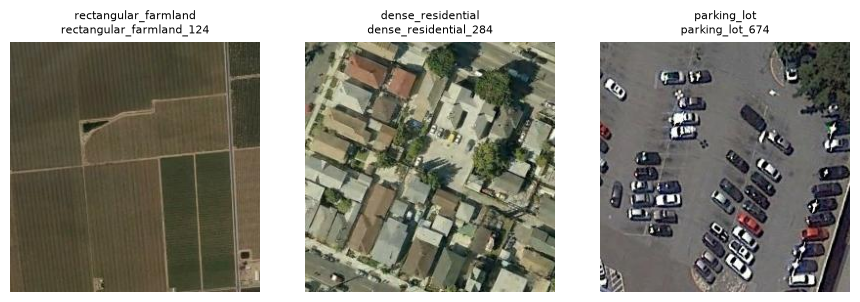

In [16]:
def show_image_batch(batch, n=3):
    n = min(n, len(batch["images"]))

    plt.figure(figsize=(3 * n, 3))

    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(batch["images"][i])
        plt.axis("off")

        title = f"{batch['class_names'][i]}\n{batch['image_ids'][i]}"
        plt.title(title, fontsize=8)

    plt.tight_layout()
    plt.show()


show_image_batch(batch, n=3)

# Part 1 — Zero-Shot Image Classification with CLIP

In this part, CLIP is used for zero-shot classification on the full RESISC45 test split.

The model is not fine-tuned.  
Instead, each class name is converted into a text prompt, and CLIP predicts the class whose text embedding is most similar to the image embedding.

This part includes prompt construction, text and image encoding, similarity computation, Top-1 accuracy, Recall@5, per-class accuracy, confusion analysis, and visual inspection of predictions.

## 1.1 Define the canonical zero-shot prompt

Each class is represented by one text prompt.

Because RESISC45 contains satellite and aerial images, the prompt is written in a remote-sensing style:

`a satellite image of a {class_name}`

In [17]:
CANONICAL_PROMPT_TEMPLATE = "a satellite image of a {}"


def build_zero_shot_prompts(class_names_clean, template):
    return [
        template.format(class_name)
        for class_name in class_names_clean
    ]


zero_shot_prompts = build_zero_shot_prompts(
    class_names_clean=class_names_clean,
    template=CANONICAL_PROMPT_TEMPLATE,
)

print("Number of classes:", len(class_names_clean))
print("Number of prompts:", len(zero_shot_prompts))
print("Prompt template:", CANONICAL_PROMPT_TEMPLATE)

Number of classes: 45
Number of prompts: 45
Prompt template: a satellite image of a {}


## 1.2 Build a zero-shot CLIP classifier

This class implements the main zero-shot classification steps:

1. encode text prompts,
2. encode image batches,
3. normalize embeddings,
4. compute image-text similarities,
5. predict the most similar class.

In [18]:
class ZeroShotCLIPClassifier:
    """
    A zero-shot CLIP classifier for matching image embeddings with text prompt embeddings.

    Args:
        model: The CLIP model.
        processor: The CLIP processor for preparing text and images.
        class_names (list): Original class names.
        class_names_clean (list): Cleaned class names used in prompts.
        device: Device used for computation.
    """

    def __init__(self, model, processor, class_names, class_names_clean, device):
        """
        Initializes the zero-shot classifier and stores model-related attributes.

        Args:
            model: The CLIP model.
            processor: The CLIP processor.
            class_names (list): List of class names.
            class_names_clean (list): List of cleaned class names.
            device: Computation device.

        Returns:
            None
        """
        ################## TODO ##################
        self.model = model
        self.processor = processor
        self.class_names = list(class_names)
        self.class_names_clean = list(class_names_clean)
        self.device = torch.device(device)
        self.model.eval()
        self.logit_scale = self.model.logit_scale.exp().detach()
        self.prompt_template = None
        self.prompts = None
        self.text_features = None
        ##########################################

    def build_prompts(self, template):
        """
        Builds one text prompt for each class using a prompt template.

        Args:
            template (str): Prompt template containing one placeholder.
                - Example: "a satellite image of a {}"

        Returns:
            list: A list of text prompts.
                - Length: num_classes
        """
        ################## TODO ##################
        self.prompt_template = template
        self.prompts = [
            template.format(class_name)
            for class_name in self.class_names_clean
        ]
        return self.prompts
        ##########################################

    def move_inputs_to_device(self, inputs):
        """
        Moves processor outputs to the selected device.

        Args:
            inputs (dict): A dictionary of input tensors.

        Returns:
            dict: A dictionary with all tensors moved to the target device.
        """
        ################## TODO ##################
        return {
            key: value.to(self.device) if torch.is_tensor(value) else value
            for key, value in inputs.items()
        }
        ##########################################

    @torch.no_grad()
    def encode_text_prompts(self, prompts, batch_size=64):
        """
        Encodes text prompts into normalized CLIP text embeddings.

        Args:
            prompts (list): List of text prompts.
                - Length: num_classes
            batch_size (int, optional): Number of prompts per batch. Defaults to 64.

        Returns:
            Tensor: Normalized text embeddings.
                - Shape: (num_classes, embedding_dim)
        """
        ################## TODO ##################
        self.model.eval()
        feature_batches = []

        for start_index in range(0, len(prompts), batch_size):
            prompt_batch = prompts[start_index:start_index + batch_size]
            inputs = self.processor(
                text=prompt_batch,
                padding=True,
                truncation=True,
                return_tensors="pt",
            )
            inputs = self.move_inputs_to_device(inputs)
            text_outputs = self.model.text_model(
                input_ids=inputs["input_ids"],
                attention_mask=inputs.get("attention_mask"),
            )
            features = self.model.text_projection(text_outputs.pooler_output)
            features = F.normalize(features, p=2, dim=-1)
            feature_batches.append(features)

        self.prompts = list(prompts)
        self.text_features = torch.cat(feature_batches, dim=0)
        return self.text_features
        ##########################################

    @torch.no_grad()
    def encode_image_batch(self, images):
        """
        Encodes a batch of images into normalized CLIP image embeddings.

        Args:
            images (list): List of PIL images.
                - Length: batch_size

        Returns:
            Tensor: Normalized image embeddings.
                - Shape: (batch_size, embedding_dim)
        """
        ################## TODO ##################
        self.model.eval()
        inputs = self.processor(
            images=images,
            return_tensors="pt",
        )
        inputs = self.move_inputs_to_device(inputs)
        vision_outputs = self.model.vision_model(
            pixel_values=inputs["pixel_values"],
        )
        features = self.model.visual_projection(vision_outputs.pooler_output)
        return F.normalize(features, p=2, dim=-1)
        ##########################################

    @torch.no_grad()
    def predict_image_batch(self, images, top_k=5):
        """
        Predicts zero-shot classes for a batch of images using image-text similarity.

        Args:
            images (list): List of PIL images.
                - Length: batch_size
            top_k (int, optional): Number of top predictions to return. Defaults to 5.

        Returns:
            dict: A dictionary containing image features, logits, probabilities,
            predicted labels, top-k indices, and top-k probabilities.
        """
        ################## TODO ##################
        if self.text_features is None:
            raise RuntimeError("Text features are not available. Encode prompts first.")

        image_features = self.encode_image_batch(images)
        text_features = self.text_features.to(self.device)
        logits = self.logit_scale.to(self.device) * image_features @ text_features.T
        probabilities = logits.softmax(dim=-1)
        effective_top_k = min(int(top_k), probabilities.shape[1])
        top_probabilities, top_indices = probabilities.topk(
            effective_top_k,
            dim=-1,
        )
        predictions = top_indices[:, 0]

        return {
            "image_features": image_features,
            "logits": logits,
            "probabilities": probabilities,
            "predictions": predictions,
            "top_indices": top_indices,
            "top_probabilities": top_probabilities,
        }
        ##########################################

## 1.3 Initialize the classifier and encode text prompts

This cell creates the zero-shot classifier and encodes all class prompts once.

The resulting text embeddings are reused for all image batches during evaluation.

In [19]:
zero_shot_classifier = ZeroShotCLIPClassifier(
    model=model,
    processor=processor,
    class_names=class_names,
    class_names_clean=class_names_clean,
    device=DEVICE,
)

zero_shot_prompts = zero_shot_classifier.build_prompts(
    template=CANONICAL_PROMPT_TEMPLATE,
)

text_features = zero_shot_classifier.encode_text_prompts(
    prompts=zero_shot_prompts,
    batch_size=64,
)

print("Text features shape:", text_features.shape)
print("CLIP logit scale:", float(zero_shot_classifier.logit_scale.detach().cpu()))

Text features shape: torch.Size([45, 768])
CLIP logit scale: 100.0


## 1.4 Evaluate zero-shot classification on the test split

This cell evaluates CLIP on the full test split.

For each image, it stores the true label, predicted label, image embedding, logits, probabilities, and Top-5 predicted classes.

In [20]:
def compute_top1_accuracy(true_labels, predicted_labels):
    """
    Computes Top-1 accuracy between true and predicted labels.

    Args:
        true_labels (array-like): Ground-truth class labels.
            - Shape: (num_samples)
        predicted_labels (array-like): Predicted class labels.
            - Shape: (num_samples)

    Returns:
        float: Top-1 accuracy score.
    """
    ################## TODO ##################
    if torch.is_tensor(true_labels):
        true_labels = true_labels.detach().cpu().numpy()
    if torch.is_tensor(predicted_labels):
        predicted_labels = predicted_labels.detach().cpu().numpy()

    true_labels = np.asarray(true_labels).reshape(-1)
    predicted_labels = np.asarray(predicted_labels).reshape(-1)

    if true_labels.shape != predicted_labels.shape:
        raise ValueError("true_labels and predicted_labels must have the same shape.")
    if true_labels.size == 0:
        return 0.0

    return float(np.mean(true_labels == predicted_labels))
    ##########################################


def compute_recall_at_k(true_labels, top_k_indices, k=5):
    """
    Computes Recall@K by checking whether the true label appears in the top-k predictions.

    Args:
        true_labels (array-like): Ground-truth class labels.
            - Shape: (num_samples)
        top_k_indices (array-like): Top-k predicted class indices.
            - Shape: (num_samples, top_k)
        k (int, optional): Number of top predictions to check. Defaults to 5.

    Returns:
        float: Recall@K score.
    """
    ################## TODO ##################
    if torch.is_tensor(true_labels):
        true_labels = true_labels.detach().cpu().numpy()
    if torch.is_tensor(top_k_indices):
        top_k_indices = top_k_indices.detach().cpu().numpy()

    true_labels = np.asarray(true_labels).reshape(-1)
    top_k_indices = np.asarray(top_k_indices)

    if top_k_indices.ndim != 2 or top_k_indices.shape[0] != true_labels.shape[0]:
        raise ValueError("top_k_indices must have shape (num_samples, top_k).")
    if true_labels.size == 0:
        return 0.0

    effective_k = min(int(k), top_k_indices.shape[1])
    hits = (top_k_indices[:, :effective_k] == true_labels[:, None]).any(axis=1)
    return float(hits.mean())
    ##########################################


@torch.no_grad()
def evaluate_zero_shot_classifier(classifier, dataloader, top_k=5):
    """
    Evaluates the zero-shot CLIP classifier on a dataloader.

    Args:
        classifier (ZeroShotCLIPClassifier): The zero-shot classifier.
        dataloader (DataLoader): Dataloader containing image batches.
        top_k (int, optional): Number of top predictions to store. Defaults to 5.

    Returns:
        dict: Evaluation results including embeddings, logits, probabilities,
        predictions, labels, Top-1 accuracy, Recall@5, and elapsed time.
    """
    ################## TODO ##################
    classifier.model.eval()
    start_time = time.time()

    image_feature_batches = []
    logit_batches = []
    probability_batches = []
    prediction_batches = []
    top_index_batches = []
    top_probability_batches = []
    label_batches = []
    image_ids = []

    for batch in tqdm(dataloader, desc="Zero-shot evaluation"):
        outputs = classifier.predict_image_batch(
            images=batch["images"],
            top_k=top_k,
        )

        image_feature_batches.append(outputs["image_features"].detach().cpu())
        logit_batches.append(outputs["logits"].detach().cpu())
        probability_batches.append(outputs["probabilities"].detach().cpu())
        prediction_batches.append(outputs["predictions"].detach().cpu())
        top_index_batches.append(outputs["top_indices"].detach().cpu())
        top_probability_batches.append(outputs["top_probabilities"].detach().cpu())
        label_batches.append(batch["labels"].detach().cpu())
        image_ids.extend(batch["image_ids"])

    image_features = torch.cat(image_feature_batches, dim=0)
    logits = torch.cat(logit_batches, dim=0)
    probabilities = torch.cat(probability_batches, dim=0)
    predictions = torch.cat(prediction_batches, dim=0)
    top_indices = torch.cat(top_index_batches, dim=0)
    top_probabilities = torch.cat(top_probability_batches, dim=0)
    labels = torch.cat(label_batches, dim=0)

    return {
        "image_features": image_features,
        "logits": logits,
        "probabilities": probabilities,
        "predictions": predictions,
        "top_indices": top_indices,
        "top_probabilities": top_probabilities,
        "labels": labels,
        "image_ids": image_ids,
        "top1_accuracy": compute_top1_accuracy(labels, predictions),
        "recall_at_5": compute_recall_at_k(labels, top_indices, k=5),
        "elapsed_time": time.time() - start_time,
        "prompt_templates": [classifier.prompt_template],
        "prompts": list(classifier.prompts),
    }
    ##########################################


def build_prediction_dataframe(results, class_names, prompts):
    """
    Builds a dataframe containing prediction details for each evaluated image.

    Args:
        results (dict): Output dictionary from evaluate_zero_shot_classifier.
        class_names (list): List of class names.
        prompts (list): List of zero-shot text prompts.

    Returns:
        DataFrame: A dataframe with true labels, predictions, confidence,
        correctness, and top-k prediction information.
    """
    ################## TODO ##################
    labels = results["labels"].detach().cpu().numpy().astype(int)
    predictions = results["predictions"].detach().cpu().numpy().astype(int)
    top_indices = results["top_indices"].detach().cpu().numpy().astype(int)
    top_probabilities = results["top_probabilities"].detach().cpu().numpy()
    probabilities = results["probabilities"].detach().cpu().numpy()

    rows = []

    for row_index in range(len(labels)):
        true_label = int(labels[row_index])
        pred_label = int(predictions[row_index])
        row = {
            "row_index": row_index,
            "image_id": results["image_ids"][row_index],
            "true_label": true_label,
            "true_class": class_names[true_label],
            "pred_label": pred_label,
            "pred_class": class_names[pred_label],
            "confidence": float(probabilities[row_index, pred_label]),
            "correct": bool(true_label == pred_label),
            "pred_prompt": prompts[pred_label],
        }

        for rank in range(top_indices.shape[1]):
            class_index = int(top_indices[row_index, rank])
            row[f"top{rank + 1}_label"] = class_index
            row[f"top{rank + 1}_class"] = class_names[class_index]
            row[f"top{rank + 1}_probability"] = float(top_probabilities[row_index, rank])

        rows.append(row)

    return pd.DataFrame(rows)
    ##########################################


zero_shot_results = evaluate_zero_shot_classifier(
    classifier=zero_shot_classifier,
    dataloader=test_loader,
    top_k=5,
)

# Reuse this variable in Part 4 instead of re-evaluating base CLIP.
base_full_test_results = zero_shot_results

df_zero_shot_predictions = build_prediction_dataframe(
    results=zero_shot_results,
    class_names=class_names,
    prompts=zero_shot_prompts,
)

true_labels_np = zero_shot_results["labels"].numpy()
pred_labels_np = zero_shot_results["predictions"].numpy()
top_indices_np = zero_shot_results["top_indices"].numpy()

zero_shot_accuracy = zero_shot_results["top1_accuracy"]
zero_shot_recall_at_5 = zero_shot_results["recall_at_5"]

print("Zero-shot classification results")
print("--------------------------------")
print("Evaluation split: full test")
print("Prompt template:", CANONICAL_PROMPT_TEMPLATE)
print("Images:", len(true_labels_np))
print("Classes:", num_classes)
print(f"Top-1 Accuracy: {zero_shot_accuracy:.4f}")
print(f"Recall@5:       {zero_shot_recall_at_5:.4f}")
print(f"Elapsed time:   {zero_shot_results['elapsed_time']:.2f} seconds")

print("\nStored objects for later parts:")
print("- zero_shot_results")
print("- base_full_test_results")
print("- df_zero_shot_predictions")

Zero-shot evaluation:   0%|          | 0/394 [00:00<?, ?it/s]

Zero-shot classification results
--------------------------------
Evaluation split: full test
Prompt template: a satellite image of a {}
Images: 6300
Classes: 45
Top-1 Accuracy: 0.6779
Recall@5:       0.9475
Elapsed time:   396.97 seconds

Stored objects for later parts:
- zero_shot_results
- base_full_test_results
- df_zero_shot_predictions


## 1.5 Per-class accuracy

This cell computes accuracy for each class separately.

For single-label classification, per-class accuracy is equivalent to per-class recall.

In [21]:
def compute_per_class_accuracy(prediction_df, class_names):
    """
    Computes accuracy separately for each class.

    Args:
        prediction_df (DataFrame): Dataframe containing prediction results.
        class_names (list): List of class names.

    Returns:
        DataFrame: A dataframe with class id, class name, total samples,
        correct predictions, and per-class accuracy.
    """
    ################## TODO ##################
    rows = []

    for class_id, class_name in enumerate(class_names):
        class_df = prediction_df[prediction_df["true_label"] == class_id]
        total = int(len(class_df))
        correct = int(class_df["correct"].sum()) if total > 0 else 0

        rows.append({
            "class_id": class_id,
            "class_name": class_name,
            "total": total,
            "correct": correct,
            "accuracy": float(correct / total) if total > 0 else np.nan,
        })

    return pd.DataFrame(rows)
    ##########################################


df_per_class_accuracy = compute_per_class_accuracy(
    prediction_df=df_zero_shot_predictions,
    class_names=class_names,
)

df_per_class_accuracy_sorted = df_per_class_accuracy.sort_values(
    by="accuracy",
    ascending=False,
).reset_index(drop=True)

display(df_per_class_accuracy_sorted)

print("Best classes:")
display(df_per_class_accuracy_sorted.head(5))

print("Worst classes:")
display(df_per_class_accuracy_sorted.tail(5))

,class_id,class_name,total,correct,accuracy
0,15,golf_course,122,122,1.000000
1,28,parking_lot,135,132,0.977778
2,31,rectangular_farmland,135,132,0.977778
3,17,harbor,142,137,0.964789
4,33,roundabout,134,129,0.962687
5,24,mobile_home_park,164,157,0.957317
6,21,lake,131,122,0.931298
7,4,beach,130,120,0.923077
8,39,stadium,142,131,0.922535
9,40,storage_tank,137,126,0.919708


Best classes:


,class_id,class_name,total,correct,accuracy
0,15,golf_course,122,122,1.000000
1,28,parking_lot,135,132,0.977778
2,31,rectangular_farmland,135,132,0.977778
3,17,harbor,142,137,0.964789
4,33,roundabout,134,129,0.962687


Worst classes:


,class_id,class_name,total,correct,accuracy
40,1,airport,162,40,0.246914
41,23,medium_residential,147,20,0.136054
42,25,mountain,115,15,0.130435
43,38,sparse_residential,130,8,0.061538
44,42,terrace,127,1,0.007874


## 1.6 Confusion matrix

This cell plots the normalized confusion matrix.

It shows which true classes are correctly predicted and which classes are confused with each other.

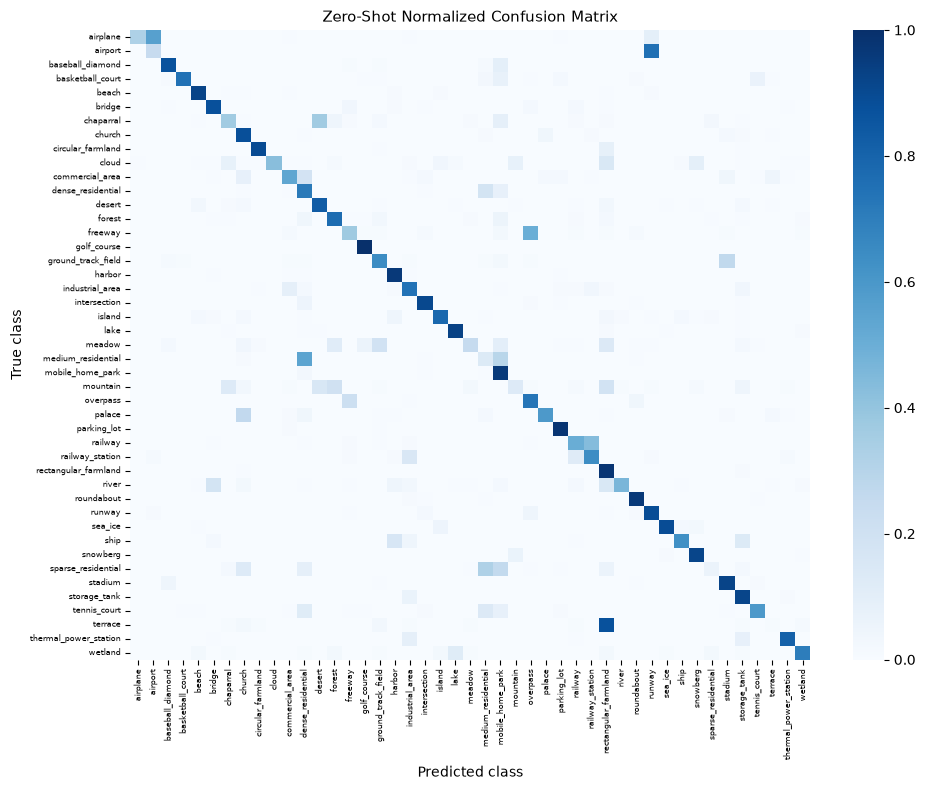

In [22]:
cm = confusion_matrix(
    true_labels_np,
    pred_labels_np,
    labels=list(range(num_classes)),
)

cm_normalized = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_normalized,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot=False,
    cbar=True,
    vmin=0,
    vmax=1,
)

plt.title("Zero-Shot Normalized Confusion Matrix", fontsize=11)
plt.xlabel("Predicted class")
plt.ylabel("True class")

plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)

plt.tight_layout()
plt.show()

## 1.7 Most frequent confusion pairs

This cell lists the most common wrong predictions.

In [23]:
def get_top_confusions(confusion_matrix_array, class_names, top_n=15):
    """
    Extracts the most frequent incorrect prediction pairs from a confusion matrix.

    Args:
        confusion_matrix_array (array-like): Confusion matrix.
            - Shape: (num_classes, num_classes)
        class_names (list): List of class names.
        top_n (int, optional): Number of confusion pairs to return. Defaults to 15.

    Returns:
        DataFrame: A dataframe containing true class, predicted class, and count.
    """
    ################## TODO ##################
    confusion_matrix_array = np.asarray(confusion_matrix_array)
    rows = []

    for true_class_id in range(confusion_matrix_array.shape[0]):
        for predicted_class_id in range(confusion_matrix_array.shape[1]):
            if true_class_id == predicted_class_id:
                continue

            count = int(confusion_matrix_array[true_class_id, predicted_class_id])

            if count > 0:
                rows.append({
                    "true_class_id": true_class_id,
                    "true_class": class_names[true_class_id],
                    "predicted_class_id": predicted_class_id,
                    "predicted_class": class_names[predicted_class_id],
                    "count": count,
                })

    columns = [
        "true_class_id",
        "true_class",
        "predicted_class_id",
        "predicted_class",
        "count",
    ]

    return (
        pd.DataFrame(rows, columns=columns)
        .sort_values(by="count", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )
    ##########################################


df_top_confusions = get_top_confusions(
    confusion_matrix_array=cm,
    class_names=class_names,
    top_n=15,
)

display(df_top_confusions)

,true_class_id,true_class,predicted_class_id,predicted_class,count
0,1,airport,34,runway,122
1,42,terrace,31,rectangular_farmland,111
2,0,airplane,1,airport,95
3,23,medium_residential,11,dense_residential,80
4,29,railway,30,railway_station,61
5,14,freeway,26,overpass,59
6,6,chaparral,12,desert,48
7,23,medium_residential,24,mobile_home_park,43
8,38,sparse_residential,23,medium_residential,42
9,27,palace,7,church,37


## 1.8 Visualize confident correct predictions

This cell shows examples where CLIP predicted the correct class with high confidence.

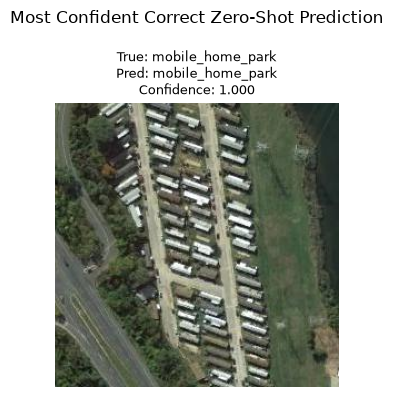

In [24]:
def show_prediction_examples(prediction_df, hf_dataset, title, n=1):
    """
    Displays prediction examples with true class, predicted class, and confidence.

    Args:
        prediction_df (DataFrame): Dataframe containing prediction results.
        hf_dataset: Hugging Face dataset split used to load images.
        title (str): Title of the visualization.
        n (int, optional): Number of examples to display. Defaults to 1.

    Returns:
        None
    """
    ################## TODO ##################
    selected_df = prediction_df.head(n).reset_index(drop=True)

    if selected_df.empty:
        print("No prediction examples are available.")
        return

    plt.figure(figsize=(4 * len(selected_df), 4))

    for plot_index, row in selected_df.iterrows():
        sample = hf_dataset[int(row["row_index"])]
        image = sample["image"].convert("RGB")

        plt.subplot(1, len(selected_df), plot_index + 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(
            f"True: {row['true_class']}\n"
            f"Pred: {row['pred_class']}\n"
            f"Confidence: {row['confidence']:.3f}",
            fontsize=9,
        )

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()
    ##########################################


df_confident_correct = (
    df_zero_shot_predictions[df_zero_shot_predictions["correct"]]
    .sort_values(by="confidence", ascending=False)
)

show_prediction_examples(
    prediction_df=df_confident_correct,
    hf_dataset=test_full_ds,
    title="Most Confident Correct Zero-Shot Prediction",
    n=1,
)

## 1.9 Visualize confident incorrect predictions

This cell shows high-confidence mistakes.

These examples help identify failure cases of zero-shot CLIP on remote-sensing images.

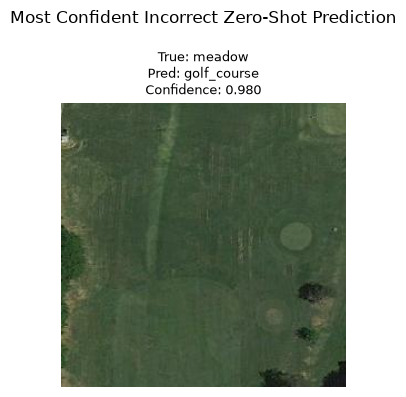

In [25]:
df_confident_errors = (
    df_zero_shot_predictions[~df_zero_shot_predictions["correct"]]
    .sort_values(by="confidence", ascending=False)
)

show_prediction_examples(
    prediction_df=df_confident_errors,
    hf_dataset=test_full_ds,
    title="Most Confident Incorrect Zero-Shot Prediction",
    n=1,
)

# Part 2 — Embedding Extraction and Visualization

In this part, we analyze the CLIP image embeddings from Part 1.

The goal is to study how RESISC45 images are organized in the CLIP embedding space before fine-tuning.

This part includes embedding loading, normalization, PCA, t-SNE, class centroid analysis, class compactness, and nearest-neighbor consistency.

## 2.1 Section configuration

This cell defines the main settings for PCA, t-SNE, and nearest-neighbor analysis.

In [26]:
PCA_N_COMPONENTS_FOR_TSNE = 50
TSNE_N_COMPONENTS = 2
TSNE_PERPLEXITY = 30
TSNE_MAX_ITER = 1000

NEAREST_NEIGHBORS_K = 10

print("Part 2 configuration")
print("--------------------")
print("PCA components before t-SNE:", PCA_N_COMPONENTS_FOR_TSNE)
print("t-SNE perplexity:", TSNE_PERPLEXITY)
print("Nearest neighbors k:", NEAREST_NEIGHBORS_K)

Part 2 configuration
--------------------
PCA components before t-SNE: 50
t-SNE perplexity: 30
Nearest neighbors k: 10


## 2.2 Load image embeddings

This cell loads the image embeddings saved during zero-shot evaluation in Part 1.


In [27]:
def get_embeddings_from_part1():
    if "zero_shot_results" not in globals():
        raise RuntimeError(
            "zero_shot_results was not found. Run Part 1 before Part 2."
        )

    required_keys = [
        "image_features",
        "labels",
        "image_ids",
        "predictions",
        "probabilities",
    ]

    missing_keys = [
        key
        for key in required_keys
        if key not in zero_shot_results
    ]

    if missing_keys:
        raise KeyError(f"Missing keys in zero_shot_results: {missing_keys}")

    return {
        "image_features": zero_shot_results["image_features"],
        "labels": zero_shot_results["labels"],
        "image_ids": zero_shot_results["image_ids"],
        "source": "part1_zero_shot_results",
    }


embedding_output = get_embeddings_from_part1()

image_embeddings = embedding_output["image_features"]
embedding_labels = embedding_output["labels"]
embedding_image_ids = embedding_output["image_ids"]

print("Embedding source:", embedding_output["source"])
print("Image embeddings shape:", image_embeddings.shape)
print("Labels shape:", embedding_labels.shape)
print("Number of image ids:", len(embedding_image_ids))

Embedding source: part1_zero_shot_results
Image embeddings shape: torch.Size([6300, 768])
Labels shape: torch.Size([6300])
Number of image ids: 6300


## 2.3 Build the embedding dataframe

This cell creates a dataframe that connects each embedding to its image ID, true class, predicted class, confidence, and correctness.

In [28]:
def build_embedding_dataframe(labels, image_ids, class_names):
    labels_np = labels.detach().cpu().numpy().astype(int)

    rows = []

    for row_index, label_id in enumerate(labels_np):
        rows.append({
            "row_index": row_index,
            "image_id": image_ids[row_index],
            "label_id": int(label_id),
            "class_name": class_names[int(label_id)],
        })

    return pd.DataFrame(rows)


df_embeddings = build_embedding_dataframe(
    labels=embedding_labels,
    image_ids=embedding_image_ids,
    class_names=class_names,
)

if "df_zero_shot_predictions" not in globals():
    raise RuntimeError(
        "df_zero_shot_predictions was not found. Run Part 1 before Part 2."
    )

prediction_columns = [
    "row_index",
    "pred_label",
    "pred_class",
    "confidence",
    "correct",
]

df_embeddings = df_embeddings.merge(
    df_zero_shot_predictions[prediction_columns],
    on="row_index",
    how="left",
)

display(df_embeddings.head())

print("Embedding dataframe shape:", df_embeddings.shape)
print("Number of unique classes:", df_embeddings["class_name"].nunique())
print("Zero-shot accuracy in dataframe:", df_embeddings["correct"].mean())

,row_index,image_id,label_id,class_name,pred_label,pred_class,confidence,correct
0,0,rectangular_farmland_124,31,rectangular_farmland,31,rectangular_farmland,0.829950,True
1,1,dense_residential_284,11,dense_residential,11,dense_residential,0.555267,True
2,2,parking_lot_674,28,parking_lot,28,parking_lot,0.996362,True
3,3,thermal_power_station_536,43,thermal_power_station,43,thermal_power_station,0.995840,True
4,4,tennis_court_162,41,tennis_court,41,tennis_court,0.903208,True


Embedding dataframe shape: (6300, 8)
Number of unique classes: 45
Zero-shot accuracy in dataframe: 0.677936507936508


## 2.4 Convert embeddings to NumPy and normalize

CLIP embeddings are compared with cosine similarity.

Therefore, this cell converts embeddings to NumPy and applies L2-normalization.

In [29]:
def l2_normalize_numpy(array, eps=1e-12):
    """
    Applies L2-normalization to each row of a NumPy array.

    Args:
        array (array-like): Input embedding matrix.
            - Shape: (num_samples, embedding_dim)
        eps (float, optional): Small value to avoid division by zero. Defaults to 1e-12.

    Returns:
        ndarray: Row-normalized embedding matrix.
            - Shape: (num_samples, embedding_dim)
    """
    ################## TODO ##################
    array = np.asarray(array, dtype=np.float32)
    norms = np.linalg.norm(array, axis=1, keepdims=True)
    return array / np.maximum(norms, eps)
    ##########################################


X_clip = image_embeddings.detach().cpu().numpy().astype(np.float32)
y_labels = embedding_labels.detach().cpu().numpy().astype(int)

X_clip_norm = l2_normalize_numpy(X_clip)

norms = np.linalg.norm(X_clip_norm, axis=1)

print("Embedding matrix:", X_clip_norm.shape)
print("Minimum norm:", norms.min())
print("Maximum norm:", norms.max())
print("Mean norm:", norms.mean())

Embedding matrix: (6300, 768)
Minimum norm: 0.9999999
Maximum norm: 1.0000001
Mean norm: 1.0


## 2.5 Dimensionality reduction helper class

This helper class applies PCA and t-SNE to high-dimensional CLIP embeddings.

PCA is used for linear projection, while t-SNE is used for local neighborhood visualization.

In [30]:
class EmbeddingProjector:
    """
    A helper class for applying PCA and t-SNE to embedding vectors.

    Args:
        random_state (int, optional): Random seed for reproducibility. Defaults to 42.
    """

    def __init__(self, random_state=42):
        """
        Initializes the projector and stores PCA/t-SNE models.

        Args:
            random_state (int, optional): Random seed for reproducibility. Defaults to 42.

        Returns:
            None
        """
        ################## TODO ##################
        self.random_state = random_state
        self.pca_model = None
        self.tsne_model = None
        ##########################################

    def fit_pca(self, embeddings, n_components=50):
        """
        Fits PCA on embeddings and returns the projected features.

        Args:
            embeddings (array-like): Input embedding matrix.
                - Shape: (num_samples, embedding_dim)
            n_components (int, optional): Number of PCA components. Defaults to 50.

        Returns:
            ndarray: PCA-projected embeddings.
                - Shape: (num_samples, n_components)
        """
        ################## TODO ##################
        embeddings = np.asarray(embeddings, dtype=np.float32)
        effective_components = min(
            int(n_components),
            embeddings.shape[0],
            embeddings.shape[1],
        )
        self.pca_model = PCA(
            n_components=effective_components,
            random_state=self.random_state,
        )
        return self.pca_model.fit_transform(embeddings)
        ##########################################

    def fit_tsne(self, embeddings, perplexity=30, max_iter=1000):
        """
        Fits t-SNE on embeddings and returns a 2D projection.

        Args:
            embeddings (array-like): Input embedding matrix.
                - Shape: (num_samples, embedding_dim)
            perplexity (int, optional): t-SNE perplexity value. Defaults to 30.
            max_iter (int, optional): Maximum number of optimization iterations. Defaults to 1000.

        Returns:
            ndarray: Two-dimensional t-SNE projection.
                - Shape: (num_samples, 2)
        """
        ################## TODO ##################
        embeddings = np.asarray(embeddings, dtype=np.float32)
        effective_perplexity = min(float(perplexity), max(1.0, embeddings.shape[0] - 1.0))
        self.tsne_model = TSNE(
            n_components=2,
            perplexity=effective_perplexity,
            max_iter=max_iter,
            init="pca",
            learning_rate="auto",
            random_state=self.random_state,
        )
        return self.tsne_model.fit_transform(embeddings)
        ##########################################

## 2.6 Compute PCA and t-SNE projections

This cell first applies PCA and then runs t-SNE on the PCA features.


In [31]:
projector = EmbeddingProjector(
    random_state=RANDOM_SEED,
)

X_pca = projector.fit_pca(
    embeddings=X_clip_norm,
    n_components=PCA_N_COMPONENTS_FOR_TSNE,
)

explained_variance = projector.pca_model.explained_variance_ratio_
cumulative_explained_variance = explained_variance.cumsum()

print("PCA output shape:", X_pca.shape)
print(f"Explained variance by first component: {explained_variance[0]:.4f}")
print(f"Cumulative explained variance: {cumulative_explained_variance[-1]:.4f}")

X_tsne = projector.fit_tsne(
    embeddings=X_pca,
    perplexity=TSNE_PERPLEXITY,
    max_iter=TSNE_MAX_ITER,
)

print("t-SNE output shape:", X_tsne.shape)

PCA output shape: (6300, 50)
Explained variance by first component: 0.0946
Cumulative explained variance: 0.7318
t-SNE output shape: (6300, 2)


## 2.7 Add projection coordinates to the dataframe

This cell adds PCA and t-SNE coordinates to the embedding dataframe for later visualization and analysis.

In [32]:
df_embeddings["pca_1"] = X_pca[:, 0]
df_embeddings["pca_2"] = X_pca[:, 1]

df_embeddings["tsne_1"] = X_tsne[:, 0]
df_embeddings["tsne_2"] = X_tsne[:, 1]

display(df_embeddings[[
    "row_index",
    "image_id",
    "class_name",
    "pred_class",
    "confidence",
    "correct",
    "pca_1",
    "pca_2",
    "tsne_1",
    "tsne_2",
]].head())

,row_index,image_id,class_name,pred_class,confidence,correct,pca_1,pca_2,tsne_1,tsne_2
0,0,rectangular_farmland_124,rectangular_farmland,rectangular_farmland,0.829950,True,0.037566,0.131429,-4.247016,57.167206
1,1,dense_residential_284,dense_residential,dense_residential,0.555267,True,-0.242115,0.101732,-31.552582,20.762367
2,2,parking_lot_674,parking_lot,parking_lot,0.996362,True,-0.180501,0.036417,-41.387760,4.509394
3,3,thermal_power_station_536,thermal_power_station,thermal_power_station,0.995840,True,0.117934,-0.258592,-16.060034,-57.558598
4,4,tennis_court_162,tennis_court,tennis_court,0.903208,True,-0.225086,0.146745,-52.611996,16.692474


## 2.8 Plot PCA projection by class

This cell visualizes the global structure of CLIP image embeddings using PCA.

Each point represents one test image.

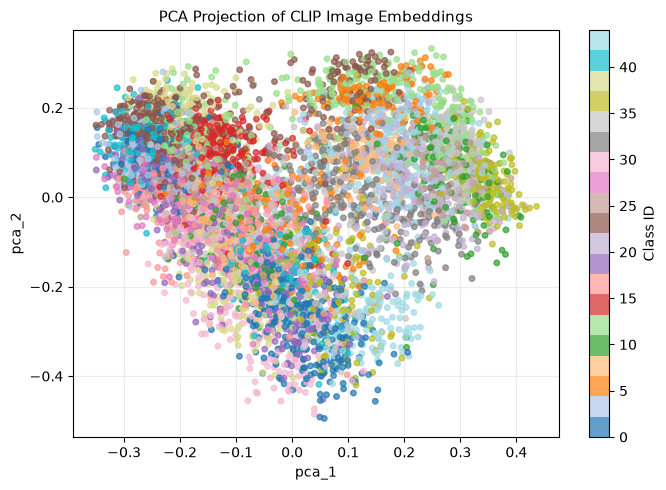

In [33]:
def plot_2d_projection_by_label(
    dataframe,
    x_col,
    y_col,
    label_col,
    title,
    figsize=(7, 5),
    point_size=16,
    alpha=0.70,
):
    plt.figure(figsize=figsize)

    scatter = plt.scatter(
        dataframe[x_col],
        dataframe[y_col],
        c=dataframe[label_col],
        cmap="tab20",
        s=point_size,
        alpha=alpha,
    )

    plt.title(title, fontsize=11)
    plt.xlabel(x_col)
    plt.ylabel(y_col)

    cbar = plt.colorbar(scatter)
    cbar.set_label("Class ID")

    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_2d_projection_by_label(
    dataframe=df_embeddings,
    x_col="pca_1",
    y_col="pca_2",
    label_col="label_id",
    title="PCA Projection of CLIP Image Embeddings",
)

## 2.9 Plot t-SNE projection by class

This cell visualizes local neighborhoods in the CLIP embedding space using t-SNE.

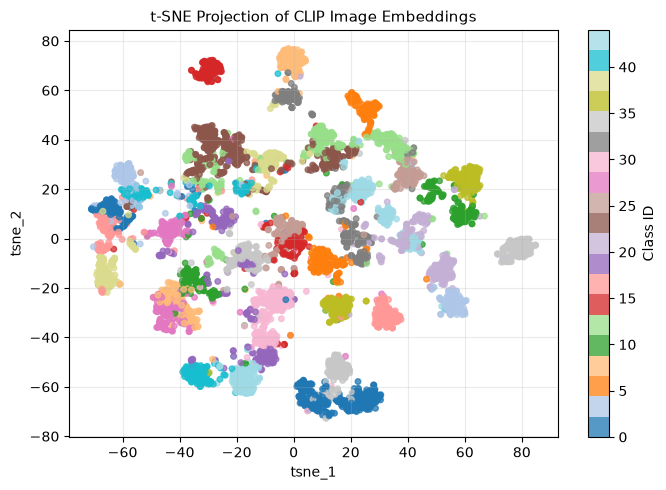

In [34]:
plot_2d_projection_by_label(
    dataframe=df_embeddings,
    x_col="tsne_1",
    y_col="tsne_2",
    label_col="label_id",
    title="t-SNE Projection of CLIP Image Embeddings",
    figsize=(7, 5),
    point_size=16,
    alpha=0.75,
)

## 2.10 Plot correct and incorrect zero-shot predictions in t-SNE space

This cell shows where correct and incorrect zero-shot predictions appear in the t-SNE embedding space.

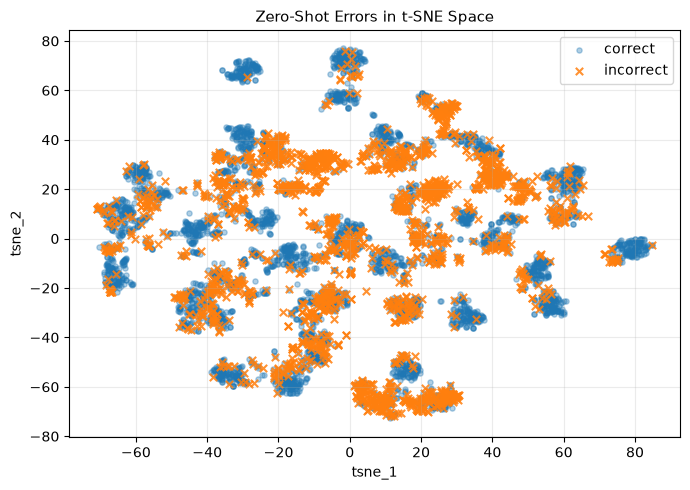

In [35]:
def plot_correctness_on_tsne(dataframe):
    if "correct" not in dataframe.columns:
        print("Prediction correctness is not available.")
        return

    correct_df = dataframe[dataframe["correct"] == True]
    error_df = dataframe[dataframe["correct"] == False]

    plt.figure(figsize=(7, 5))

    plt.scatter(
        correct_df["tsne_1"],
        correct_df["tsne_2"],
        s=14,
        alpha=0.35,
        label="correct",
    )

    plt.scatter(
        error_df["tsne_1"],
        error_df["tsne_2"],
        s=28,
        alpha=0.85,
        marker="x",
        label="incorrect",
    )

    plt.title("Zero-Shot Errors in t-SNE Space", fontsize=11)
    plt.xlabel("tsne_1")
    plt.ylabel("tsne_2")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_correctness_on_tsne(df_embeddings)

## 2.11 Supervised embedding analyzer

This cell analyzes the embedding space using class labels.

It computes class centroids, class compactness, closest class pairs, and nearest-neighbor consistency.

In [36]:
def compute_class_centroids(embeddings, labels, class_names):
    """
    Computes one normalized centroid and compactness statistics for each class.

    Args:
        embeddings (array-like): Normalized image embeddings.
            - Shape: (num_samples, embedding_dim)
        labels (array-like): Class labels for each embedding.
            - Shape: (num_samples)
        class_names (list): List of class names.
            - Length: num_classes

    Returns:
        tuple: A tuple containing:
            - centroids (ndarray): Normalized class centroids.
                - Shape: (num_classes, embedding_dim)
            - dataframe (DataFrame): Per-class compactness statistics.
    """
    ################## TODO ##################
    embeddings = l2_normalize_numpy(embeddings)
    labels = np.asarray(labels).astype(int)
    centroids = np.zeros(
        (len(class_names), embeddings.shape[1]),
        dtype=np.float32,
    )
    rows = []

    for class_id, class_name in enumerate(class_names):
        class_embeddings = embeddings[labels == class_id]

        if len(class_embeddings) == 0:
            rows.append({
                "class_id": class_id,
                "class_name": class_name,
                "num_samples": 0,
                "mean_cosine_similarity": np.nan,
                "mean_cosine_distance": np.nan,
                "std_cosine_distance": np.nan,
            })
            continue

        centroid = class_embeddings.mean(axis=0, keepdims=True)
        centroid = l2_normalize_numpy(centroid)[0]
        centroids[class_id] = centroid
        similarities = class_embeddings @ centroid
        distances = 1.0 - similarities

        rows.append({
            "class_id": class_id,
            "class_name": class_name,
            "num_samples": len(class_embeddings),
            "mean_cosine_similarity": float(similarities.mean()),
            "mean_cosine_distance": float(distances.mean()),
            "std_cosine_distance": float(distances.std()),
        })

    return centroids, pd.DataFrame(rows)
    ##########################################


def compute_closest_centroid_pairs(centroids, class_names, top_n=10):
    """
    Finds the closest class pairs based on centroid cosine distance.

    Args:
        centroids (array-like): Normalized class centroid vectors.
            - Shape: (num_classes, embedding_dim)
        class_names (list): List of class names.
            - Length: num_classes
        top_n (int, optional): Number of closest pairs to return. Defaults to 10.

    Returns:
        DataFrame: Closest class pairs with cosine similarity and distance.
    """
    ################## TODO ##################
    centroids = l2_normalize_numpy(centroids)
    rows = []

    for first_class_id in range(len(class_names)):
        for second_class_id in range(first_class_id + 1, len(class_names)):
            similarity = float(centroids[first_class_id] @ centroids[second_class_id])
            rows.append({
                "class_id_1": first_class_id,
                "class_name_1": class_names[first_class_id],
                "class_id_2": second_class_id,
                "class_name_2": class_names[second_class_id],
                "cosine_similarity": similarity,
                "cosine_distance": 1.0 - similarity,
            })

    return (
        pd.DataFrame(rows)
        .sort_values(by="cosine_distance", ascending=True)
        .head(top_n)
        .reset_index(drop=True)
    )
    ##########################################


def compute_nearest_neighbor_consistency(embeddings, labels, class_names, k=10):
    """
    Computes how often each image's nearest neighbors belong to the same class.

    Args:
        embeddings (array-like): Normalized image embeddings.
            - Shape: (num_samples, embedding_dim)
        labels (array-like): Class labels for each embedding.
            - Shape: (num_samples)
        class_names (list): List of class names.
            - Length: num_classes
        k (int, optional): Number of nearest neighbors to check. Defaults to 10.

    Returns:
        tuple: A tuple containing:
            - dataframe (DataFrame): Per-class nearest-neighbor consistency.
            - point_df (DataFrame): Per-image same-class neighbor ratio.
    """
    ################## TODO ##################
    embeddings = l2_normalize_numpy(embeddings)
    labels = np.asarray(labels).astype(int)
    effective_k = min(int(k), max(0, len(embeddings) - 1))

    if effective_k == 0:
        point_ratios = np.zeros(len(embeddings), dtype=np.float32)
    else:
        neighbor_model = NearestNeighbors(
            n_neighbors=effective_k + 1,
            metric="cosine",
        )
        neighbor_model.fit(embeddings)
        neighbor_indices = neighbor_model.kneighbors(
            embeddings,
            return_distance=False,
        )[:, 1:]
        point_ratios = (
            labels[neighbor_indices] == labels[:, None]
        ).mean(axis=1)

    point_df = pd.DataFrame({
        "row_index": np.arange(len(embeddings)),
        "same_class_neighbor_ratio": point_ratios,
    })

    rows = []

    for class_id, class_name in enumerate(class_names):
        class_ratios = point_ratios[labels == class_id]
        rows.append({
            "class_id": class_id,
            "class_name": class_name,
            "num_samples": int(len(class_ratios)),
            "mean_same_class_neighbor_ratio": float(class_ratios.mean()) if len(class_ratios) else np.nan,
            "std_same_class_neighbor_ratio": float(class_ratios.std()) if len(class_ratios) else np.nan,
        })

    return pd.DataFrame(rows), point_df
    ##########################################


class_centroids, df_class_compactness = compute_class_centroids(
    embeddings=X_clip_norm,
    labels=y_labels,
    class_names=class_names,
)

df_class_compactness_sorted = df_class_compactness.sort_values(
    by="mean_cosine_distance",
    ascending=True,
).reset_index(drop=True)

df_centroid_distances = compute_closest_centroid_pairs(
    centroids=class_centroids,
    class_names=class_names,
    top_n=10,
)

df_nn_consistency, df_point_nn = compute_nearest_neighbor_consistency(
    embeddings=X_clip_norm,
    labels=y_labels,
    class_names=class_names,
    k=NEAREST_NEIGHBORS_K,
)

df_nn_consistency_sorted = df_nn_consistency.sort_values(
    by="mean_same_class_neighbor_ratio",
    ascending=False,
).reset_index(drop=True)

df_embeddings = df_embeddings.merge(
    df_point_nn,
    on="row_index",
    how="left",
)

print("Most compact classes:")
display(df_class_compactness_sorted.head(5))

print("Least compact classes:")
display(df_class_compactness_sorted.tail(5))

print("Closest class centroid pairs:")
display(df_centroid_distances)

print("Highest nearest-neighbor consistency:")
display(df_nn_consistency_sorted.head(5))

print("Lowest nearest-neighbor consistency:")
display(df_nn_consistency_sorted.tail(5))

Most compact classes:


,class_id,class_name,num_samples,mean_cosine_similarity,mean_cosine_distance,std_cosine_distance
0,8,circular_farmland,146,0.936120,0.063880,0.032172
1,15,golf_course,122,0.920028,0.079972,0.031585
2,35,sea_ice,151,0.915256,0.084744,0.039256
3,6,chaparral,132,0.912733,0.087267,0.042380
4,26,overpass,150,0.911462,0.088538,0.030677


Least compact classes:


,class_id,class_name,num_samples,mean_cosine_similarity,mean_cosine_distance,std_cosine_distance
40,21,lake,131,0.863150,0.136850,0.033002
41,20,island,139,0.858568,0.141432,0.050975
42,39,stadium,142,0.853562,0.146438,0.035013
43,7,church,143,0.849422,0.150578,0.036550
44,27,palace,140,0.840038,0.159962,0.035083


Closest class centroid pairs:


,class_id_1,class_name_1,class_id_2,class_name_2,cosine_similarity,cosine_distance
0,7,church,27,palace,0.962228,0.037772
1,14,freeway,26,overpass,0.961150,0.038850
2,11,dense_residential,23,medium_residential,0.959711,0.040289
3,29,railway,30,railway_station,0.955781,0.044219
4,13,forest,22,meadow,0.954518,0.045482
5,23,medium_residential,24,mobile_home_park,0.953021,0.046979
6,31,rectangular_farmland,42,terrace,0.942051,0.057949
7,23,medium_residential,38,sparse_residential,0.939767,0.060233
8,3,basketball_court,41,tennis_court,0.938244,0.061756
9,18,industrial_area,30,railway_station,0.937927,0.062073


Highest nearest-neighbor consistency:


,class_id,class_name,num_samples,mean_same_class_neighbor_ratio,std_same_class_neighbor_ratio
0,35,sea_ice,151,0.995364,0.031175
1,15,golf_course,122,0.986885,0.084883
2,6,chaparral,132,0.982576,0.066851
3,37,snowberg,159,0.975472,0.082962
4,17,harbor,142,0.969014,0.125138


Lowest nearest-neighbor consistency:


,class_id,class_name,num_samples,mean_same_class_neighbor_ratio,std_same_class_neighbor_ratio
40,23,medium_residential,147,0.670748,0.243615
41,14,freeway,118,0.649153,0.284261
42,7,church,143,0.644056,0.266975
43,30,railway_station,154,0.633766,0.288575
44,27,palace,140,0.575714,0.276424


## 2.12 Build class centroid projection

This cell projects class centroids into two dimensions with PCA.

The plot gives a compact view of high-level relationships between classes.

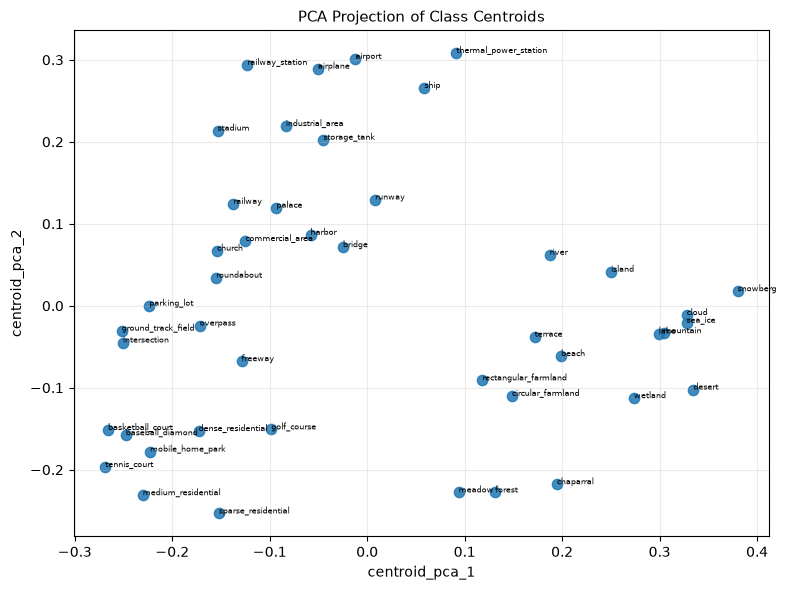

In [37]:
centroid_projector = EmbeddingProjector(
    random_state=RANDOM_SEED,
)

centroid_pca = centroid_projector.fit_pca(
    embeddings=class_centroids,
    n_components=2,
)

df_centroids = pd.DataFrame({
    "class_id": np.arange(len(class_names)),
    "class_name": class_names,
    "centroid_pca_1": centroid_pca[:, 0],
    "centroid_pca_2": centroid_pca[:, 1],
})

plt.figure(figsize=(8, 6))

plt.scatter(
    df_centroids["centroid_pca_1"],
    df_centroids["centroid_pca_2"],
    s=55,
    alpha=0.85,
)

for _, row in df_centroids.iterrows():
    plt.text(
        row["centroid_pca_1"],
        row["centroid_pca_2"],
        row["class_name"],
        fontsize=6,
    )

plt.title("PCA Projection of Class Centroids", fontsize=11)
plt.xlabel("centroid_pca_1")
plt.ylabel("centroid_pca_2")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Part 3 — Prompt Engineering for Zero-Shot Classification

In this part, we study how prompt wording affects CLIP zero-shot classification.

The image embeddings stay fixed, and only the text prompts are changed.  
This isolates the effect of the text side of CLIP.

This part includes single-prompt evaluation, per-class prompt sensitivity, and prompt ensembling.

## 3.1 Define prompt templates

This cell defines several prompt templates for RESISC45 classes.

The prompts include generic image descriptions and remote-sensing-specific descriptions.

In [38]:
PROMPT_BANK = {
    "minimal": "{}",
    "photo": "a photo of a {}",
    "image": "an image of a {}",
    "satellite_canonical": "a satellite image of a {}",
    "remote_sensing": "a remote sensing image of a {}",
    "aerial": "an aerial image of a {}",
    "overhead": "an overhead view of a {}",
    "high_res_satellite": "a high resolution satellite image of a {}",
    "cropped_satellite": "a cropped satellite image of a {}",
}

PROMPT_GROUPS = {
    "generic_prompts": [
        "minimal",
        "photo",
        "image",
    ],
    "domain_prompts": [
        "satellite_canonical",
        "remote_sensing",
        "aerial",
        "overhead",
    ],
    "strong_domain_prompts": [
        "satellite_canonical",
        "remote_sensing",
        "aerial",
        "high_res_satellite",
        "cropped_satellite",
    ],
}

CANONICAL_PROMPT_ID = "satellite_canonical"

print("Number of prompt templates:", len(PROMPT_BANK))
print("Canonical prompt:", PROMPT_BANK[CANONICAL_PROMPT_ID])

display(
    pd.DataFrame([
        {
            "prompt_id": prompt_id,
            "template": template,
        }
        for prompt_id, template in PROMPT_BANK.items()
    ])
)

Number of prompt templates: 9
Canonical prompt: a satellite image of a {}


,prompt_id,template
0,minimal,{}
1,photo,a photo of a {}
2,image,an image of a {}
3,satellite_canonical,a satellite image of a {}
4,remote_sensing,a remote sensing image of a {}
5,aerial,an aerial image of a {}
6,overhead,an overhead view of a {}
7,high_res_satellite,a high resolution satellite image of a {}
8,cropped_satellite,a cropped satellite image of a {}


## 3.2 Prepare embeddings for prompt evaluation

This cell prepares fixed image embeddings and labels for prompt evaluation.

Using fixed image embeddings makes the experiment faster and focuses only on prompt effects.

In [39]:
def get_prompt_experiment_data():
    if "X_clip_norm" in globals() and "y_labels" in globals():
        return {
            "image_features": X_clip_norm.astype(np.float32),
            "labels": y_labels.astype(int),
            "image_ids": df_embeddings["image_id"].tolist() if "df_embeddings" in globals() else None,
            "source": "part2_normalized_embeddings",
        }

    if "zero_shot_results" in globals():
        image_features = zero_shot_results["image_features"].detach().cpu().numpy().astype(np.float32)
        image_features = l2_normalize_numpy(image_features)

        return {
            "image_features": image_features,
            "labels": zero_shot_results["labels"].detach().cpu().numpy().astype(int),
            "image_ids": zero_shot_results["image_ids"],
            "source": "part1_zero_shot_results",
        }

    raise RuntimeError(
        "No image embeddings were found. Run Part 1 or Part 2 before Part 3."
    )


prompt_data = get_prompt_experiment_data()

prompt_image_features = prompt_data["image_features"]
prompt_labels = prompt_data["labels"]
prompt_image_ids = prompt_data["image_ids"]
prompt_data_source = prompt_data["source"]

print("Prompt experiment data")
print("----------------------")
print("Data source:", prompt_data_source)
print("Image features:", prompt_image_features.shape)
print("Labels:", prompt_labels.shape)
print("Image ids:", len(prompt_image_ids) if prompt_image_ids is not None else None)

Prompt experiment data
----------------------
Data source: part2_normalized_embeddings
Image features: (6300, 768)
Labels: (6300,)
Image ids: 6300


## 3.3 Define a prompt evaluator

This class evaluates zero-shot classification for different prompt templates.

It recomputes text embeddings and compares them with the fixed image embeddings.

In [40]:
class PromptTemplateEvaluator:
    """
    Evaluates different prompt templates for zero-shot CLIP classification.

    Args:
        model: The CLIP model.
        processor: The CLIP processor for tokenizing text.
        class_names (list): Original class names.
        class_names_clean (list): Cleaned class names used inside prompts.
        device: Device used for computation.
    """

    def __init__(self, model, processor, class_names, class_names_clean, device):
        """
        Initializes the prompt evaluator.

        Args:
            model: The CLIP model.
            processor: The CLIP processor.
            class_names (list): List of class names.
            class_names_clean (list): List of cleaned class names.
            device: Computation device.

        Returns:
            None
        """
        ################## TODO ##################
        self.model = model
        self.processor = processor
        self.class_names = list(class_names)
        self.class_names_clean = list(class_names_clean)
        self.device = torch.device(device)
        self.model.eval()
        ##########################################

    def move_inputs_to_device(self, inputs):
        """
        Moves processor outputs to the selected device.

        Args:
            inputs (dict): Dictionary of input tensors.

        Returns:
            dict: Input tensors moved to the target device.
        """
        ################## TODO ##################
        return {
            key: value.to(self.device) if torch.is_tensor(value) else value
            for key, value in inputs.items()
        }
        ##########################################

    @torch.no_grad()
    def encode_texts(self, texts, batch_size=64):
        """
        Encodes a list of texts into normalized CLIP text embeddings.

        Args:
            texts (list): List of text prompts.
                - Length: num_texts
            batch_size (int, optional): Number of texts per batch. Defaults to 64.

        Returns:
            Tensor: Normalized text embeddings.
                - Shape: (num_texts, embedding_dim)
        """
        ################## TODO ##################
        self.model.eval()
        feature_batches = []

        for start_index in range(0, len(texts), batch_size):
            text_batch = texts[start_index:start_index + batch_size]
            inputs = self.processor(
                text=text_batch,
                padding=True,
                truncation=True,
                return_tensors="pt",
            )
            inputs = self.move_inputs_to_device(inputs)
            text_outputs = self.model.text_model(
                input_ids=inputs["input_ids"],
                attention_mask=inputs.get("attention_mask"),
            )
            features = self.model.text_projection(text_outputs.pooler_output)
            feature_batches.append(F.normalize(features, p=2, dim=-1))

        return torch.cat(feature_batches, dim=0)
        ##########################################

    def build_text_features_from_templates(self, templates):
        """
        Builds class-level text embeddings from one or more prompt templates.

        Args:
            templates (str or list): One prompt template or a list of prompt templates.

        Returns:
            Tensor: Normalized text embedding for each class.
                - Shape: (num_classes, embedding_dim)
        """
        ################## TODO ##################
        if isinstance(templates, str):
            templates = [templates]

        template_features = []

        for template in templates:
            prompts = [
                template.format(class_name)
                for class_name in self.class_names_clean
            ]
            template_features.append(self.encode_texts(prompts))

        text_features = torch.stack(template_features, dim=0).mean(dim=0)
        return F.normalize(text_features, p=2, dim=-1)
        ##########################################

    def evaluate_text_features(self, image_features, labels, text_features, top_k=5):
        """
        Evaluates image-text similarity using fixed image features and text features.

        Args:
            image_features (array-like): Normalized image embeddings.
                - Shape: (num_samples, embedding_dim)
            labels (array-like): Ground-truth class labels.
                - Shape: (num_samples)
            text_features (Tensor): Normalized text embeddings.
                - Shape: (num_classes, embedding_dim)
            top_k (int, optional): Number of top predictions to evaluate. Defaults to 5.

        Returns:
            dict: Evaluation outputs including accuracy, Recall@K, predictions,
            probabilities, confidence scores, and logits.
        """
        ################## TODO ##################
        image_features = torch.as_tensor(
            image_features,
            dtype=torch.float32,
            device=self.device,
        )
        image_features = F.normalize(image_features, p=2, dim=-1)
        text_features = F.normalize(
            text_features.to(self.device, dtype=torch.float32),
            p=2,
            dim=-1,
        )
        labels = np.asarray(labels).astype(int)
        logits = self.model.logit_scale.exp().detach().to(self.device) * image_features @ text_features.T
        probabilities = logits.softmax(dim=-1)
        effective_top_k = min(int(top_k), probabilities.shape[1])
        top_probabilities, top_indices = probabilities.topk(effective_top_k, dim=-1)
        predictions = top_indices[:, 0]

        predictions_np = predictions.detach().cpu().numpy()
        top_indices_np = top_indices.detach().cpu().numpy()

        return {
            "top1_accuracy": compute_top1_accuracy(labels, predictions_np),
            "recall_at_5": compute_recall_at_k(labels, top_indices_np, k=5),
            "predictions": predictions_np,
            "top_indices": top_indices_np,
            "top_probabilities": top_probabilities.detach().cpu().numpy(),
            "probabilities": probabilities.detach().cpu().numpy(),
            "confidence": top_probabilities[:, 0].detach().cpu().numpy(),
            "logits": logits.detach().cpu().numpy(),
        }
        ##########################################

    def evaluate_prompt_bank(self, prompt_bank, image_features, labels, top_k=5):
        """
        Evaluates all prompt templates in a prompt bank.

        Args:
            prompt_bank (dict): Mapping from prompt id to prompt template.
            image_features (array-like): Normalized image embeddings.
                - Shape: (num_samples, embedding_dim)
            labels (array-like): Ground-truth class labels.
                - Shape: (num_samples)
            top_k (int, optional): Number of top predictions to evaluate. Defaults to 5.

        Returns:
            tuple: A tuple containing:
                - results_df (DataFrame): Prompt-level evaluation results.
                - predictions (dict): Predicted labels for each prompt id.
        """
        ################## TODO ##################
        rows = []
        predictions = {}

        for prompt_id, prompt_template in tqdm(prompt_bank.items(), desc="Prompt evaluation"):
            text_features = self.build_text_features_from_templates(prompt_template)
            result = self.evaluate_text_features(
                image_features=image_features,
                labels=labels,
                text_features=text_features,
                top_k=top_k,
            )
            rows.append({
                "prompt_id": prompt_id,
                "prompt_template": prompt_template,
                "top1_accuracy": result["top1_accuracy"],
                "recall_at_5": result["recall_at_5"],
            })
            predictions[prompt_id] = result["predictions"]

        results_df = (
            pd.DataFrame(rows)
            .sort_values(by="top1_accuracy", ascending=False)
            .reset_index(drop=True)
        )
        return results_df, predictions
        ##########################################

## 3.4 Evaluate all single prompt templates

This cell evaluates each prompt template independently.

The results show how much zero-shot accuracy depends on prompt wording.

In [41]:
prompt_evaluator = PromptTemplateEvaluator(
    model=model,
    processor=processor,
    class_names=class_names,
    class_names_clean=class_names_clean,
    device=DEVICE,
)

df_prompt_results, prompt_predictions = prompt_evaluator.evaluate_prompt_bank(
    prompt_bank=PROMPT_BANK,
    image_features=prompt_image_features,
    labels=prompt_labels,
    top_k=5,
)

best_prompt_id = df_prompt_results.iloc[0]["prompt_id"]
best_prompt_template = df_prompt_results.iloc[0]["prompt_template"]

canonical_prompt_row = df_prompt_results[
    df_prompt_results["prompt_id"] == CANONICAL_PROMPT_ID
].iloc[0]

display(df_prompt_results)

print("Canonical prompt")
print("----------------")
print("Prompt ID:", CANONICAL_PROMPT_ID)
print("Template:", PROMPT_BANK[CANONICAL_PROMPT_ID])
print(f"Top-1 accuracy: {canonical_prompt_row['top1_accuracy']:.4f}")
print(f"Recall@5:       {canonical_prompt_row['recall_at_5']:.4f}")

print("\nBest single prompt")
print("------------------")
print("Prompt ID:", best_prompt_id)
print("Template:", best_prompt_template)
print(f"Top-1 accuracy: {df_prompt_results.iloc[0]['top1_accuracy']:.4f}")
print(f"Recall@5:       {df_prompt_results.iloc[0]['recall_at_5']:.4f}")

Prompt evaluation:   0%|          | 0/9 [00:00<?, ?it/s]

,prompt_id,prompt_template,top1_accuracy,recall_at_5
0,aerial,an aerial image of a {},0.710317,0.953968
1,cropped_satellite,a cropped satellite image of a {},0.684603,0.945079
2,overhead,an overhead view of a {},0.683651,0.937619
3,satellite_canonical,a satellite image of a {},0.677937,0.947460
4,remote_sensing,a remote sensing image of a {},0.677143,0.941746
5,high_res_satellite,a high resolution satellite image of a {},0.671587,0.943651
6,image,an image of a {},0.660635,0.919365
7,photo,a photo of a {},0.630635,0.907619
8,minimal,{},0.593016,0.891111


Canonical prompt
----------------
Prompt ID: satellite_canonical
Template: a satellite image of a {}
Top-1 accuracy: 0.6779
Recall@5:       0.9475

Best single prompt
------------------
Prompt ID: aerial
Template: an aerial image of a {}
Top-1 accuracy: 0.7103
Recall@5:       0.9540


## 3.5 Compute per-class prompt accuracy

This cell measures prompt sensitivity for each class.

Some classes may be stable across prompts, while others may depend strongly on wording.

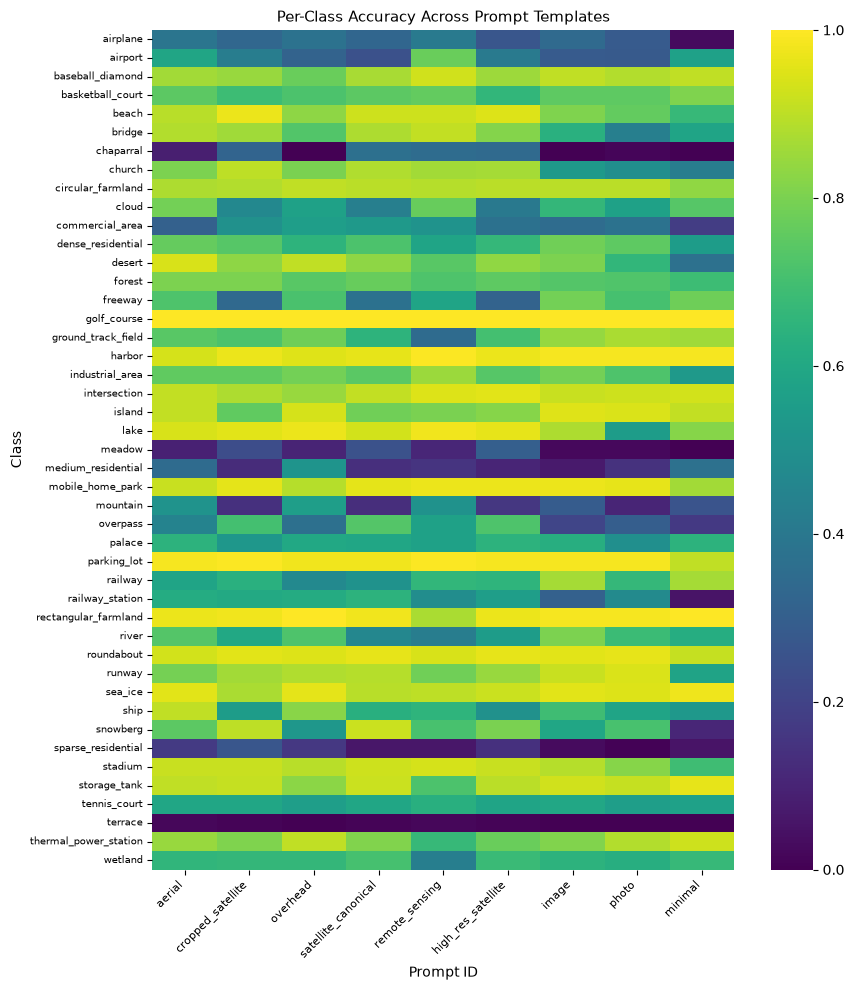

In [42]:
def compute_per_class_prompt_accuracy(prompt_predictions, labels, class_names):
    """
    Computes per-class accuracy for each prompt template.

    Args:
        prompt_predictions (dict): Mapping from prompt id to predicted labels.
            - Each value shape: (num_samples)
        labels (array-like): Ground-truth class labels.
            - Shape: (num_samples)
        class_names (list): List of class names.
            - Length: num_classes

    Returns:
        DataFrame: Per-class accuracy for each prompt template.
    """
    ################## TODO ##################
    labels = np.asarray(labels).astype(int)
    rows = []

    for prompt_id, predictions in prompt_predictions.items():
        if torch.is_tensor(predictions):
            predictions = predictions.detach().cpu().numpy()
        predictions = np.asarray(predictions).astype(int)

        for class_id, class_name in enumerate(class_names):
            class_mask = labels == class_id
            total = int(class_mask.sum())
            correct = int((predictions[class_mask] == class_id).sum()) if total > 0 else 0
            rows.append({
                "prompt_id": prompt_id,
                "class_id": class_id,
                "class_name": class_name,
                "total": total,
                "correct": correct,
                "accuracy": float(correct / total) if total > 0 else np.nan,
            })

    return pd.DataFrame(rows)
    ##########################################


df_per_class_prompt_accuracy = compute_per_class_prompt_accuracy(
    prompt_predictions=prompt_predictions,
    labels=prompt_labels,
    class_names=class_names,
)

per_class_prompt_matrix = df_per_class_prompt_accuracy.pivot(
    index="class_name",
    columns="prompt_id",
    values="accuracy",
)

ordered_prompt_ids = df_prompt_results["prompt_id"].tolist()
per_class_prompt_matrix = per_class_prompt_matrix[ordered_prompt_ids]

plt.figure(figsize=(9, 10))

sns.heatmap(
    per_class_prompt_matrix,
    cmap="viridis",
    vmin=0,
    vmax=1,
    annot=False,
    cbar=True,
)

plt.title("Per-Class Accuracy Across Prompt Templates", fontsize=11)
plt.xlabel("Prompt ID")
plt.ylabel("Class")

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=7)

plt.tight_layout()
plt.show()

## 3.6 Template ensembling

This cell evaluates prompt ensembling.

Instead of using one prompt per class, multiple text embeddings are averaged to reduce dependence on a single template.

In [43]:
def evaluate_prompt_ensembles(
    evaluator,
    prompt_bank,
    ensemble_specs,
    image_features,
    labels,
    top_k=5,
):
    """
    Evaluates prompt ensembles by averaging text embeddings from multiple templates.

    Args:
        evaluator (PromptTemplateEvaluator): Prompt evaluator object.
        prompt_bank (dict): Mapping from prompt id to prompt template.
        ensemble_specs (dict): Mapping from ensemble id to a list of prompt ids.
        image_features (array-like): Normalized image embeddings.
            - Shape: (num_samples, embedding_dim)
        labels (array-like): Ground-truth class labels.
            - Shape: (num_samples)
        top_k (int, optional): Number of top predictions to evaluate. Defaults to 5.

    Returns:
        tuple: A tuple containing:
            - results_df (DataFrame): Prompt ensemble evaluation results.
            - predictions (dict): Predicted labels for each ensemble id.
    """
    ################## TODO ##################
    rows = []
    predictions = {}

    for ensemble_id, prompt_ids in ensemble_specs.items():
        missing_prompt_ids = [
            prompt_id
            for prompt_id in prompt_ids
            if prompt_id not in prompt_bank
        ]

        if missing_prompt_ids:
            raise KeyError(f"Unknown prompt ids: {missing_prompt_ids}")

        templates = [prompt_bank[prompt_id] for prompt_id in prompt_ids]
        text_features = evaluator.build_text_features_from_templates(templates)
        result = evaluator.evaluate_text_features(
            image_features=image_features,
            labels=labels,
            text_features=text_features,
            top_k=top_k,
        )

        rows.append({
            "method_type": "prompt_ensemble",
            "method_id": ensemble_id,
            "description": ", ".join(prompt_ids),
            "num_prompts": len(prompt_ids),
            "top1_accuracy": result["top1_accuracy"],
            "recall_at_5": result["recall_at_5"],
        })
        predictions[ensemble_id] = result["predictions"]

    results_df = (
        pd.DataFrame(rows)
        .sort_values(by="top1_accuracy", ascending=False)
        .reset_index(drop=True)
    )
    return results_df, predictions
    ##########################################

top3_prompt_ids = df_prompt_results.head(3)["prompt_id"].tolist()

PROMPT_ENSEMBLES = {
    "domain_ensemble": PROMPT_GROUPS["domain_prompts"],
    "strong_domain_ensemble": PROMPT_GROUPS["strong_domain_prompts"],
    "top3_single_prompt_ensemble": top3_prompt_ids,
}

df_prompt_ensemble_results, ensemble_predictions = evaluate_prompt_ensembles(
    evaluator=prompt_evaluator,
    prompt_bank=PROMPT_BANK,
    ensemble_specs=PROMPT_ENSEMBLES,
    image_features=prompt_image_features,
    labels=prompt_labels,
    top_k=5,
)

single_prompt_comparison = df_prompt_results.copy()
single_prompt_comparison["method_type"] = "single_prompt"
single_prompt_comparison["method_id"] = single_prompt_comparison["prompt_id"]
single_prompt_comparison["description"] = single_prompt_comparison["prompt_template"]
single_prompt_comparison["num_prompts"] = 1

single_prompt_comparison = single_prompt_comparison[
    [
        "method_type",
        "method_id",
        "description",
        "num_prompts",
        "top1_accuracy",
        "recall_at_5",
    ]
]

df_prompt_method_comparison = pd.concat(
    [
        single_prompt_comparison,
        df_prompt_ensemble_results,
    ],
    ignore_index=True,
)

df_prompt_method_comparison = (
    df_prompt_method_comparison
    .sort_values(by="top1_accuracy", ascending=False)
    .reset_index(drop=True)
)

canonical_method_row = df_prompt_method_comparison[
    df_prompt_method_comparison["method_id"] == CANONICAL_PROMPT_ID
].iloc[0]

best_method_row = df_prompt_method_comparison.iloc[0]

BEST_SINGLE_PROMPT_ID = best_prompt_id
BEST_SINGLE_PROMPT_TEMPLATE = best_prompt_template
BEST_OVERALL_PROMPT_METHOD_ID = best_method_row["method_id"]

print("Prompt method comparison")
print("------------------------")
display(df_prompt_method_comparison)

print("Canonical vs best method")
print("------------------------")
print("Canonical method:", canonical_method_row["method_id"])
print(f"Canonical Top-1: {canonical_method_row['top1_accuracy']:.4f}")
print(f"Canonical Recall@5: {canonical_method_row['recall_at_5']:.4f}")

print("\nBest method:", BEST_OVERALL_PROMPT_METHOD_ID)
print("Method type:", best_method_row["method_type"])
print("Description:", best_method_row["description"])
print(f"Best Top-1: {best_method_row['top1_accuracy']:.4f}")
print(f"Best Recall@5: {best_method_row['recall_at_5']:.4f}")

print("\nDelta from canonical")
print("--------------------")
print(f"Top-1 delta: {best_method_row['top1_accuracy'] - canonical_method_row['top1_accuracy']:+.4f}")
print(f"Recall@5 delta: {best_method_row['recall_at_5'] - canonical_method_row['recall_at_5']:+.4f}")

Prompt method comparison
------------------------


,method_type,method_id,description,num_prompts,top1_accuracy,recall_at_5
0,prompt_ensemble,domain_ensemble,"satellite_canonical, remote_sensing, aerial, o...",4,0.713175,0.956508
1,single_prompt,aerial,an aerial image of a {},1,0.710317,0.953968
2,prompt_ensemble,top3_single_prompt_ensemble,"aerial, cropped_satellite, overhead",3,0.710317,0.954444
3,prompt_ensemble,strong_domain_ensemble,"satellite_canonical, remote_sensing, aerial, h...",5,0.699206,0.954444
4,single_prompt,cropped_satellite,a cropped satellite image of a {},1,0.684603,0.945079
5,single_prompt,overhead,an overhead view of a {},1,0.683651,0.937619
6,single_prompt,satellite_canonical,a satellite image of a {},1,0.677937,0.947460
7,single_prompt,remote_sensing,a remote sensing image of a {},1,0.677143,0.941746
8,single_prompt,high_res_satellite,a high resolution satellite image of a {},1,0.671587,0.943651
9,single_prompt,image,an image of a {},1,0.660635,0.919365


Canonical vs best method
------------------------
Canonical method: satellite_canonical
Canonical Top-1: 0.6779
Canonical Recall@5: 0.9475

Best method: domain_ensemble
Method type: prompt_ensemble
Description: satellite_canonical, remote_sensing, aerial, overhead
Best Top-1: 0.7132
Best Recall@5: 0.9565

Delta from canonical
--------------------
Top-1 delta: +0.0352
Recall@5 delta: +0.0090


### Question 1 — Prompt Wording and Zero-Shot Performance

CLIP was evaluated with different prompt templates and prompt ensembles. Compare the canonical prompt with the best prompt method. Based on the prompt comparison table, the per-class prompt heatmap, and the t-SNE error visualization, does changing the prompt significantly improve zero-shot classification?

### Answer:

best prompt method improves the canonical prompt only modestly rather than producing a major change in zero shot performance and heatmap shows that wording helps some classes but hurts or barely changes others so the gains are class dependent and t-SNE plot also shows that many errors remain near overlapping or neighboring class clusters and prompt engineering is useful for a small improvement but it does not solve the underlying visual ambiguity in the CLIP embedding space

# Part 4 — Contrastive Learning and LoRA Fine-Tuning

In this part, CLIP is adapted to RESISC45 with parameter-efficient fine-tuning.

We build class-based image-text pairs, train LoRA adapters on CLIP, optimize a supervised contrastive objective, and compare the fine-tuned model with the base zero-shot model on the full test split.

## 4.1 Check the validation split

This cell verifies that the train, validation, and full test splits are available before fine-tuning.

The validation split is used for monitoring loss during training, and the full test split is reserved for final evaluation.

In [44]:
if validation_ds is None:
    raise ValueError("Validation split is missing. Check Part 0.8 and Part 0.9.")

required_objects = [
    "train_ds",
    "validation_ds",
    "test_full_ds",
    "train_loader",
    "validation_loader",
    "test_full_loader",
    "zero_shot_results",
    "base_full_test_results",
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:
    raise RuntimeError(f"Missing required objects before Part 4: {missing_objects}")

split_check_df = pd.DataFrame([
    {
        "split": "train",
        "num_images": len(train_ds),
        "loader_batches": len(train_loader),
    },
    {
        "split": "validation",
        "num_images": len(validation_ds),
        "loader_batches": len(validation_loader),
    },
    {
        "split": "test",
        "num_images": len(test_full_ds),
        "loader_batches": len(test_full_loader),
    },
])

display(split_check_df)

print("Base CLIP results from Part 1")
print("-----------------------------")
print("Prompt templates:", base_full_test_results["prompt_templates"])
print(f"Top-1 accuracy: {base_full_test_results['top1_accuracy']:.4f}")
print(f"Recall@5:       {base_full_test_results['recall_at_5']:.4f}")

,split,num_images,loader_batches
0,train,18900,1182
1,validation,6300,394
2,test,6300,394


Base CLIP results from Part 1
-----------------------------
Prompt templates: ['a satellite image of a {}']
Top-1 accuracy: 0.6779
Recall@5:       0.9475


## 4.2 Fine-tuning configuration

This cell defines the main fine-tuning settings.

LoRA updates a low-rank correction for a frozen weight matrix,
$W' = W + \Delta W$, with $\Delta W = BA$ and rank $r \ll \min(d,k)$.
This reduces the number of trainable parameters and makes CLIP fine-tuning more memory-efficient.

The cell sets the LoRA hyperparameters, optimizer settings, batch sizes, and mixed-precision options.

In [45]:
PART4_DIR = OUTPUT_DIR / "part4_lora_finetuning"
PART4_DIR.mkdir(parents=True, exist_ok=True)

MERGED_MODEL_DIR = PART4_DIR / "clip_resisc45_lora_merged"

FT_MAX_TEXT_LENGTH = 77

################## TODO ##################
# Choose suitable LoRA hyperparameters.
# Hint: rank controls adapter capacity, alpha controls scaling,
# and dropout helps regularization.

LORA_RANK = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05
##########################################

# Attention projection layers commonly adapted with LoRA in CLIP.
LORA_TARGET_MODULES = [
    "q_proj",
    "k_proj",
    "v_proj",
    "out_proj",
]

################## TODO ##################
# Choose suitable fine-tuning hyperparameters.
# Use conservative values

FT_TRAIN_BATCH_SIZE = 4
FT_VAL_BATCH_SIZE = 8
FT_EVAL_BATCH_SIZE = 16

FT_NUM_EPOCHS = 3
FT_LEARNING_RATE = 1e-4
FT_WEIGHT_DECAY = 0.01
FT_WARMUP_RATIO = 0.10
FT_GRADIENT_ACCUMULATION_STEPS = 4
FT_MAX_GRAD_NORM = 1.0
##########################################

# These settings can usually stay fixed.
USE_AMP = torch.cuda.is_available()
ENABLE_GRADIENT_CHECKPOINTING = True

USE_TRAIN_SUBSET_FOR_DEBUG = False
TRAIN_IMAGES_PER_CLASS_DEBUG = 50

ft_config_df = pd.DataFrame([
    {"name": "CLIP model", "value": CLIP_MODEL_ID},
    {"name": "LoRA rank", "value": LORA_RANK},
    {"name": "LoRA alpha", "value": LORA_ALPHA},
    {"name": "LoRA dropout", "value": LORA_DROPOUT},
    {"name": "train batch size", "value": FT_TRAIN_BATCH_SIZE},
    {"name": "validation batch size", "value": FT_VAL_BATCH_SIZE},
    {"name": "eval batch size", "value": FT_EVAL_BATCH_SIZE},
    {"name": "gradient accumulation steps", "value": FT_GRADIENT_ACCUMULATION_STEPS},
    {"name": "effective train batch size", "value": FT_TRAIN_BATCH_SIZE * FT_GRADIENT_ACCUMULATION_STEPS},
    {"name": "epochs", "value": FT_NUM_EPOCHS},
    {"name": "learning rate", "value": FT_LEARNING_RATE},
    {"name": "mixed precision", "value": USE_AMP},
    {"name": "gradient checkpointing", "value": ENABLE_GRADIENT_CHECKPOINTING},
])

display(ft_config_df)

,name,value
0,CLIP model,openai/clip-vit-large-patch14
1,LoRA rank,8
2,LoRA alpha,16
3,LoRA dropout,0.05
4,train batch size,4
5,validation batch size,8
6,eval batch size,16
7,gradient accumulation steps,4
8,effective train batch size,16
9,epochs,3


## 4.3 Select prompt templates for fine-tuning

RESISC45 provides class labels but not natural captions, so each training image is paired with a class-based prompt.

This cell selects the prompt templates used for fine-tuning and keeps the canonical prompt for fair final evaluation.

In [46]:
def unique_list(items):
    seen = set()
    output = []

    for item in items:
        if item not in seen:
            output.append(item)
            seen.add(item)

    return output


def resolve_finetuning_prompt_templates():
    templates = []

    # Reuse the strongest single prompts found in Part 3, if available.
    if "df_prompt_results" in globals() and "PROMPT_BANK" in globals():
        top_prompt_ids = df_prompt_results.head(3)["prompt_id"].tolist()

        for prompt_id in top_prompt_ids:
            templates.append(PROMPT_BANK[prompt_id])

    # Always include domain-specific remote-sensing prompts.
    if "PROMPT_BANK" in globals():
        fallback_prompt_ids = [
            "satellite_canonical",
            "remote_sensing",
            "aerial",
            "overhead",
        ]

        for prompt_id in fallback_prompt_ids:
            if prompt_id in PROMPT_BANK:
                templates.append(PROMPT_BANK[prompt_id])

    if len(templates) == 0:
        templates = [
            "a satellite image of a {}",
            "a remote sensing image of a {}",
            "an aerial image of a {}",
            "an overhead view of a {}",
        ]

    return unique_list(templates)


FINE_TUNE_PROMPT_TEMPLATES = resolve_finetuning_prompt_templates()

# Use the same prompt as Part 1 for fair base-vs-fine-tuned comparison.
EVAL_PROMPT_TEMPLATE = CANONICAL_PROMPT_TEMPLATE
EVAL_PROMPT_TEMPLATES = [EVAL_PROMPT_TEMPLATE]

prompt_config_df = pd.DataFrame([
    {
        "usage": "fine_tuning",
        "template": template,
    }
    for template in FINE_TUNE_PROMPT_TEMPLATES
] + [
    {
        "usage": "final_evaluation",
        "template": EVAL_PROMPT_TEMPLATE,
    }
])

display(prompt_config_df)

print("Final evaluation uses the same prompt as Part 1:")
print(EVAL_PROMPT_TEMPLATE)

,usage,template
0,fine_tuning,an aerial image of a {}
1,fine_tuning,a cropped satellite image of a {}
2,fine_tuning,an overhead view of a {}
3,fine_tuning,a satellite image of a {}
4,fine_tuning,a remote sensing image of a {}
5,final_evaluation,a satellite image of a {}


Final evaluation uses the same prompt as Part 1:
a satellite image of a {}


## 4.4 Build contrastive datasets

This cell builds image-text pairs for contrastive training.

For each image, the text is generated from its class label. During training, prompts are sampled from a prompt pool to increase variation, while validation uses a fixed prompt for a more stable loss estimate.

In [47]:
class RESISC45ContrastiveDataset(Dataset):
    """
    A dataset that pairs each RESISC45 image with a class-based text caption.

    Args:
        hf_dataset: A Hugging Face dataset split.
        id2label (dict): Mapping from label id to class name.
        class_names_clean (list): Cleaned class names used in captions.
        prompt_templates (list): Prompt templates for generating captions.
        training (bool, optional): Whether to sample prompts randomly. Defaults to False.
        seed (int, optional): Random seed for prompt sampling. Defaults to 42.
    """

    def __init__(
        self,
        hf_dataset,
        id2label,
        class_names_clean,
        prompt_templates,
        training=False,
        seed=42,
    ):
        """
        Initializes the contrastive dataset.

        Returns:
            None
        """
        ################## TODO ##################
        self.hf_dataset = hf_dataset
        self.id2label = id2label
        self.class_names_clean = list(class_names_clean)
        self.prompt_templates = list(prompt_templates)
        self.training = training
        self.rng = random.Random(seed)

        if len(self.prompt_templates) == 0:
            raise ValueError("At least one prompt template is required.")
        ##########################################

    def __len__(self):
        """
        Returns the number of samples in the dataset.

        Returns:
            int: Number of samples.
        """
        ################## TODO ##################
        return len(self.hf_dataset)
        ##########################################

    def build_caption(self, label):
        """
        Builds a text caption from a class label.

        Args:
            label (int): Class label id.

        Returns:
            str: Text caption generated from the class name.
        """
        ################## TODO ##################
        class_name = self.class_names_clean[int(label)]
        template = (
            self.rng.choice(self.prompt_templates)
            if self.training
            else self.prompt_templates[0]
        )
        return template.format(class_name)
        ##########################################

    def __getitem__(self, index):
        """
        Loads one image-caption pair from the dataset.

        Args:
            index (int): Sample index.

        Returns:
            dict: A sample containing image, caption, label, class_name, and image_id.
        """
        ################## TODO ##################
        sample = self.hf_dataset[int(index)]
        label = int(sample["label"])
        image_id = sample.get("image_id", index)

        return {
            "image": sample["image"].convert("RGB"),
            "caption": self.build_caption(label),
            "label": label,
            "class_name": self.id2label[label],
            "image_id": str(image_id),
        }
        ##########################################


def clip_contrastive_collate_fn(batch):
    """
    Collates image-caption samples and prepares CLIP inputs.

    Args:
        batch (list): List of samples from RESISC45ContrastiveDataset.

    Returns:
        dict: Encoded CLIP inputs with labels, captions, class names, and image ids.
    """
    ################## TODO ##################
    images = [sample["image"] for sample in batch]
    captions = [sample["caption"] for sample in batch]
    encoded = processor(
        text=captions,
        images=images,
        padding=True,
        truncation=True,
        max_length=FT_MAX_TEXT_LENGTH,
        return_tensors="pt",
    )

    return {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
        "pixel_values": encoded["pixel_values"],
        "labels": torch.tensor(
            [sample["label"] for sample in batch],
            dtype=torch.long,
        ),
        "captions": captions,
        "class_names": [sample["class_name"] for sample in batch],
        "image_ids": [sample["image_id"] for sample in batch],
    }
    ##########################################

## 4.5 Create training and validation dataloaders

This cell creates the dataloaders used for LoRA fine-tuning.

The training loader uses the train split, and the validation loader uses the validation split. An optional balanced subset can be used for debugging.

In [48]:
if USE_TRAIN_SUBSET_FOR_DEBUG:
    debug_train_indices = balanced_subset_indices(
        train_ds,
        n_per_class=TRAIN_IMAGES_PER_CLASS_DEBUG,
        seed=RANDOM_SEED,
    )

    train_ft_hf_ds = train_ds.select(debug_train_indices)
else:
    train_ft_hf_ds = train_ds


train_contrastive_dataset = RESISC45ContrastiveDataset(
    hf_dataset=train_ft_hf_ds,
    id2label=id2label,
    class_names_clean=class_names_clean,
    prompt_templates=FINE_TUNE_PROMPT_TEMPLATES,
    training=True,
    seed=RANDOM_SEED,
)

validation_contrastive_dataset = RESISC45ContrastiveDataset(
    hf_dataset=validation_ds,
    id2label=id2label,
    class_names_clean=class_names_clean,
    prompt_templates=EVAL_PROMPT_TEMPLATES,
    training=False,
    seed=RANDOM_SEED,
)

train_contrastive_loader = DataLoader(
    train_contrastive_dataset,
    batch_size=FT_TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=clip_contrastive_collate_fn,
    pin_memory=torch.cuda.is_available(),
)

validation_contrastive_loader = DataLoader(
    validation_contrastive_dataset,
    batch_size=FT_VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=clip_contrastive_collate_fn,
    pin_memory=torch.cuda.is_available(),
)

sample_ft_batch = next(iter(train_contrastive_loader))

batch_check_df = pd.DataFrame([
    {
        "field": "input_ids",
        "shape": tuple(sample_ft_batch["input_ids"].shape),
    },
    {
        "field": "attention_mask",
        "shape": tuple(sample_ft_batch["attention_mask"].shape),
    },
    {
        "field": "pixel_values",
        "shape": tuple(sample_ft_batch["pixel_values"].shape),
    },
    {
        "field": "labels",
        "shape": tuple(sample_ft_batch["labels"].shape),
    },
])

loader_check_df = pd.DataFrame([
    {
        "loader": "train_contrastive_loader",
        "dataset_size": len(train_contrastive_dataset),
        "batch_size": FT_TRAIN_BATCH_SIZE,
        "num_batches": len(train_contrastive_loader),
    },
    {
        "loader": "validation_contrastive_loader",
        "dataset_size": len(validation_contrastive_dataset),
        "batch_size": FT_VAL_BATCH_SIZE,
        "num_batches": len(validation_contrastive_loader),
    },
])

display(loader_check_df)
display(batch_check_df)

print("Example training caption:")
print(sample_ft_batch["captions"][0])

,loader,dataset_size,batch_size,num_batches
0,train_contrastive_loader,18900,4,4725
1,validation_contrastive_loader,6300,8,788


,field,shape
0,input_ids,"(4, 11)"
1,attention_mask,"(4, 11)"
2,pixel_values,"(4, 3, 224, 224)"
3,labels,"(4,)"


Example training caption:
an aerial image of a ship


## 4.6 CLIP feature helpers

This cell defines helper functions for manually computing CLIP text and image embeddings.

The helpers keep the feature extraction path compatible with both the original CLIP model and the LoRA-wrapped PEFT model.

In [49]:
def unwrap_clip_model(clip_model):
    """
    Extracts the base CLIP model from a possible PEFT/LoRA wrapper.

    Args:
        clip_model: A CLIP model or PEFT-wrapped CLIP model.

    Returns:
        model: The underlying CLIP model with text and vision encoders.
    """
    ################## TODO ##################
    if hasattr(clip_model, "get_base_model"):
        return clip_model.get_base_model()
    return clip_model
    ##########################################


def move_batch_to_device(batch, device):
    """
    Moves tensor values in a batch to the selected device.

    Args:
        batch (dict): Batch containing tensors and non-tensor metadata.
        device: Target computation device.

    Returns:
        dict: Batch with tensor values moved to the target device.
    """
    ################## TODO ##################
    return {
        key: value.to(device, non_blocking=True) if torch.is_tensor(value) else value
        for key, value in batch.items()
    }
    ##########################################


def encode_clip_text_features_from_inputs(clip_model, input_ids, attention_mask):
    """
    Encodes tokenized text inputs into normalized CLIP text embeddings.

    Args:
        clip_model: CLIP model or PEFT-wrapped CLIP model.
        input_ids (Tensor): Token ids.
            - Shape: (batch_size, sequence_length)
        attention_mask (Tensor): Attention mask.
            - Shape: (batch_size, sequence_length)

    Returns:
        Tensor: Normalized text embeddings.
            - Shape: (batch_size, embedding_dim)
    """
    ################## TODO ##################
    base_model = unwrap_clip_model(clip_model)
    text_outputs = base_model.text_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
    )
    text_features = base_model.text_projection(text_outputs.pooler_output)
    return F.normalize(text_features, p=2, dim=-1)
    ##########################################


def encode_clip_image_features_from_inputs(clip_model, pixel_values):
    """
    Encodes image tensors into normalized CLIP image embeddings.

    Args:
        clip_model: CLIP model or PEFT-wrapped CLIP model.
        pixel_values (Tensor): Preprocessed image tensors.
            - Shape: (batch_size, 3, height, width)

    Returns:
        Tensor: Normalized image embeddings.
            - Shape: (batch_size, embedding_dim)
    """
    ################## TODO ##################
    base_model = unwrap_clip_model(clip_model)
    vision_outputs = base_model.vision_model(
        pixel_values=pixel_values,
    )
    image_features = base_model.visual_projection(vision_outputs.pooler_output)
    return F.normalize(image_features, p=2, dim=-1)
    ##########################################


def get_clip_logit_scale(clip_model):
    """
    Returns CLIP's learned logit scale.

    Args:
        clip_model: CLIP model or PEFT-wrapped CLIP model.

    Returns:
        Tensor: Exponentiated logit scale.
    """
    ################## TODO ##################
    base_model = unwrap_clip_model(clip_model)
    return base_model.logit_scale.exp().clamp(max=100.0)
    ##########################################

## 4.7 Supervised CLIP contrastive loss

This cell defines the supervised contrastive loss used for fine-tuning.

For normalized image features $v_i$ and text features $t_j$, the similarity is
$s_{ij} = \exp(\tau)\, v_i^\top t_j$.

Unlike standard CLIP loss, this implementation treats all image-text pairs with the same class label as positives inside the batch. The final objective averages the image-to-text and text-to-image supervised contrastive losses.

In [50]:
def supervised_clip_contrastive_loss(
    clip_model,
    batch,
):
    """
    Computes supervised image-text contrastive loss for CLIP.

    Args:
        clip_model: CLIP model or PEFT-wrapped CLIP model.
        batch (dict): A batch containing input_ids, attention_mask, pixel_values, and labels.

    Returns:
        Tensor: Scalar contrastive loss.
    """
    ################## TODO ##################
    text_features = encode_clip_text_features_from_inputs(
        clip_model=clip_model,
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
    )
    image_features = encode_clip_image_features_from_inputs(
        clip_model=clip_model,
        pixel_values=batch["pixel_values"],
    )
    logits = get_clip_logit_scale(clip_model) * image_features @ text_features.T
    labels = batch["labels"]
    positive_mask = labels[:, None].eq(labels[None, :])
    minimum_value = torch.finfo(logits.dtype).min

    image_positive_logits = logits.masked_fill(~positive_mask, minimum_value)
    text_positive_logits = logits.T.masked_fill(~positive_mask.T, minimum_value)

    image_to_text_loss = -(
        torch.logsumexp(image_positive_logits, dim=1)
        - torch.logsumexp(logits, dim=1)
    ).mean()
    text_to_image_loss = -(
        torch.logsumexp(text_positive_logits, dim=1)
        - torch.logsumexp(logits.T, dim=1)
    ).mean()

    return 0.5 * (image_to_text_loss + text_to_image_loss)
    ##########################################

## 4.8 Build the LoRA CLIP model

This cell loads a fresh CLIP model and inserts LoRA adapters into the attention projection layers.

Most original CLIP weights remain frozen, while only the low-rank adapter parameters are trained. The cell also reports the number of trainable parameters.

In [56]:
# Install specific versions that work together
%pip install -q torchao==0.16.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 51.8 MB/s eta 0:00:00


In [57]:
def prepare_peft_for_lora():
    """
    Prepares PEFT utilities needed for LoRA fine-tuning.

    Args:
        None

    Returns:
        tuple: LoraConfig class and get_peft_model function.
    """
    ################## TODO ##################
    try:
        from peft import LoraConfig as PeftLoraConfig
        from peft import get_peft_model as peft_get_peft_model
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "peft"])
        importlib.invalidate_caches()
        from peft import LoraConfig as PeftLoraConfig
        from peft import get_peft_model as peft_get_peft_model

    return PeftLoraConfig, peft_get_peft_model
    ##########################################


def build_lora_clip_model():
    """
    Loads a CLIP model and attaches LoRA adapters to selected attention layers.

    Args:
        None

    Returns:
        model: A PEFT-wrapped CLIP model with LoRA adapters.
    """
    ################## TODO ##################
    PeftLoraConfig, peft_get_peft_model = prepare_peft_for_lora()
    base_model = CLIPModel.from_pretrained(CLIP_MODEL_ID)

    if ENABLE_GRADIENT_CHECKPOINTING:
        try:
            base_model.gradient_checkpointing_enable(
                gradient_checkpointing_kwargs={"use_reentrant": False}
            )
        except TypeError:
            base_model.gradient_checkpointing_enable()

    lora_config = PeftLoraConfig(
        r=LORA_RANK,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGET_MODULES,
        bias="none",
    )

    return peft_get_peft_model(base_model, lora_config)
    ##########################################


def count_trainable_parameters(model_to_count):
    """
    Counts total and trainable parameters in a model.

    Args:
        model_to_count: The model whose parameters should be counted.

    Returns:
        dict: Total parameters, trainable parameters, and trainable percentage.
    """
    ################## TODO ##################
    total_params = sum(parameter.numel() for parameter in model_to_count.parameters())
    trainable_params = sum(
        parameter.numel()
        for parameter in model_to_count.parameters()
        if parameter.requires_grad
    )

    return {
        "total_params": total_params,
        "trainable_params": trainable_params,
        "trainable_percent": 100.0 * trainable_params / total_params,
    }
    ##########################################


# Move the original CLIP model from Parts 0-3 to CPU before LoRA training.
if "model" in globals():
    model.to("cpu")
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


lora_model = build_lora_clip_model()
lora_model = lora_model.to(DEVICE)

param_summary = count_trainable_parameters(lora_model)

param_summary_df = pd.DataFrame([
    {
        "metric": "total_parameters",
        "value": param_summary["total_params"],
    },
    {
        "metric": "trainable_parameters",
        "value": param_summary["trainable_params"],
    },
    {
        "metric": "trainable_percent",
        "value": param_summary["trainable_percent"],
    },
])

display(param_summary_df)

try:
    lora_model.print_trainable_parameters()
except Exception as error:
    print("Could not print PEFT parameter summary:", repr(error))

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

,metric,value
0,total_parameters,4.297792e+08
1,trainable_parameters,2.162688e+06
2,trainable_percent,5.032091e-01


trainable params: 2,162,688 || all params: 429,779,201 || trainable%: 0.5032


## 4.9 Training engine

This class manages the LoRA fine-tuning loop.

It handles optimization, gradient accumulation, mixed precision, validation loss computation, and training-history logging across epochs.

In [58]:
class CLIPLoRAFineTuner:
    """
    A training engine for LoRA fine-tuning of CLIP.

    Args:
        model: The LoRA-wrapped CLIP model.
        train_loader (DataLoader): Training dataloader.
        validation_loader (DataLoader): Validation dataloader.
        device: Computation device.
        learning_rate (float): Optimizer learning rate.
        weight_decay (float): Weight decay for AdamW.
        num_epochs (int): Number of training epochs.
        warmup_ratio (float): Fraction of steps used for learning-rate warmup.
        gradient_accumulation_steps (int): Number of batches before each optimizer step.
        max_grad_norm (float): Maximum gradient norm for clipping.
        use_amp (bool): Whether to use mixed precision.
    """

    def __init__(
        self,
        model,
        train_loader,
        validation_loader,
        device,
        learning_rate,
        weight_decay,
        num_epochs,
        warmup_ratio,
        gradient_accumulation_steps,
        max_grad_norm,
        use_amp,
    ):
        """
        Initializes the fine-tuning engine.

        Returns:
            None
        """
        ################## TODO ##################
        self.model = model
        self.train_loader = train_loader
        self.validation_loader = validation_loader
        self.device = torch.device(device)
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.num_epochs = num_epochs
        self.warmup_ratio = warmup_ratio
        self.gradient_accumulation_steps = gradient_accumulation_steps
        self.max_grad_norm = max_grad_norm
        self.use_amp = bool(use_amp and self.device.type == "cuda")
        self.optimizer = None
        self.scheduler = None

        try:
            self.scaler = torch.amp.GradScaler(
                "cuda",
                enabled=self.use_amp,
            )
        except (AttributeError, TypeError):
            self.scaler = torch.cuda.amp.GradScaler(
                enabled=self.use_amp,
            )

        self.setup_optimizer_and_scheduler()
        ##########################################

    def setup_optimizer_and_scheduler(self):
        """
        Creates the optimizer and learning-rate scheduler.

        Args:
            None

        Returns:
            None
        """
        ################## TODO ##################
        trainable_parameters = [
            parameter
            for parameter in self.model.parameters()
            if parameter.requires_grad
        ]
        self.optimizer = torch.optim.AdamW(
            trainable_parameters,
            lr=self.learning_rate,
            weight_decay=self.weight_decay,
        )
        update_steps_per_epoch = math.ceil(
            len(self.train_loader) / self.gradient_accumulation_steps
        )
        total_training_steps = update_steps_per_epoch * self.num_epochs
        warmup_steps = int(total_training_steps * self.warmup_ratio)
        self.scheduler = get_cosine_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_training_steps,
        )
        ##########################################

    def train_one_epoch(self, epoch_index):
        """
        Runs one training epoch with gradient accumulation and mixed precision.

        Args:
            epoch_index (int): Current epoch number.

        Returns:
            float: Mean training loss for the epoch.
        """
        ################## TODO ##################
        self.model.train()
        self.optimizer.zero_grad(set_to_none=True)
        total_loss = 0.0
        total_batches = 0
        progress_bar = tqdm(
            self.train_loader,
            desc=f"Training epoch {epoch_index}",
        )

        for batch_index, batch in enumerate(progress_bar):
            batch = move_batch_to_device(batch, self.device)

            with torch.autocast(
                device_type=self.device.type,
                dtype=torch.float16,
                enabled=self.use_amp,
            ):
                loss = supervised_clip_contrastive_loss(
                    clip_model=self.model,
                    batch=batch,
                )
                scaled_loss = loss / self.gradient_accumulation_steps

            self.scaler.scale(scaled_loss).backward()
            total_loss += float(loss.detach().cpu())
            total_batches += 1

            should_step = (
                (batch_index + 1) % self.gradient_accumulation_steps == 0
                or batch_index + 1 == len(self.train_loader)
            )

            if should_step:
                self.scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(
                    [
                        parameter
                        for parameter in self.model.parameters()
                        if parameter.requires_grad
                    ],
                    self.max_grad_norm,
                )
                self.scaler.step(self.optimizer)
                self.scaler.update()
                self.optimizer.zero_grad(set_to_none=True)
                self.scheduler.step()

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}",
                lr=f"{self.optimizer.param_groups[0]['lr']:.2e}",
            )

        return total_loss / max(total_batches, 1)
        ##########################################

    @torch.no_grad()
    def validate_loss(self):
        """
        Computes the validation loss without updating model parameters.

        Args:
            None

        Returns:
            float: Mean validation loss.
        """
        ################## TODO ##################
        self.model.eval()
        total_loss = 0.0
        total_batches = 0

        for batch in tqdm(self.validation_loader, desc="Validation"):
            batch = move_batch_to_device(batch, self.device)

            with torch.autocast(
                device_type=self.device.type,
                dtype=torch.float16,
                enabled=self.use_amp,
            ):
                loss = supervised_clip_contrastive_loss(
                    clip_model=self.model,
                    batch=batch,
                )

            total_loss += float(loss.detach().cpu())
            total_batches += 1

        return total_loss / max(total_batches, 1)
        ##########################################

    def fit(self):
        """
        Runs the full fine-tuning loop across all epochs.

        Args:
            None

        Returns:
            DataFrame: Training history containing train loss, validation loss, and timing.
        """
        ################## TODO ##################
        history = []

        for epoch_index in range(1, self.num_epochs + 1):
            epoch_start_time = time.time()
            train_loss = self.train_one_epoch(epoch_index)
            validation_loss = self.validate_loss()
            epoch_time_seconds = time.time() - epoch_start_time
            learning_rate = self.optimizer.param_groups[0]["lr"]

            history.append({
                "epoch": epoch_index,
                "train_loss": train_loss,
                "val_loss": validation_loss,
                "learning_rate": learning_rate,
                "epoch_time_seconds": epoch_time_seconds,
            })

            print(
                f"Epoch {epoch_index}/{self.num_epochs} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={validation_loss:.4f} | "
                f"time={epoch_time_seconds:.2f}s"
            )

        return pd.DataFrame(history)
        ##########################################

## 4.10 Run LoRA fine-tuning

This cell runs LoRA fine-tuning on the training split and evaluates the validation loss after each epoch.

The output is a training-history table that summarizes the optimization process.

In [59]:
fine_tuner = CLIPLoRAFineTuner(
    model=lora_model,
    train_loader=train_contrastive_loader,
    validation_loader=validation_contrastive_loader,
    device=DEVICE,
    learning_rate=FT_LEARNING_RATE,
    weight_decay=FT_WEIGHT_DECAY,
    num_epochs=FT_NUM_EPOCHS,
    warmup_ratio=FT_WARMUP_RATIO,
    gradient_accumulation_steps=FT_GRADIENT_ACCUMULATION_STEPS,
    max_grad_norm=FT_MAX_GRAD_NORM,
    use_amp=USE_AMP,
)

df_training_history = fine_tuner.fit()

display(
    df_training_history.round({
        "train_loss": 4,
        "val_loss": 4,
        "learning_rate": 8,
        "epoch_time_seconds": 2,
    })
)

Training epoch 1:   0%|          | 0/4725 [00:00<?, ?it/s]

Validation:   0%|          | 0/788 [00:00<?, ?it/s]

Epoch 1/3 | train_loss=0.0457 | val_loss=0.0394 | time=2147.31s


Training epoch 2:   0%|          | 0/4725 [00:00<?, ?it/s]

Validation:   0%|          | 0/788 [00:00<?, ?it/s]

Epoch 2/3 | train_loss=0.0143 | val_loss=0.0315 | time=1954.79s


Training epoch 3:   0%|          | 0/4725 [00:00<?, ?it/s]

Validation:   0%|          | 0/788 [00:00<?, ?it/s]

Epoch 3/3 | train_loss=0.0073 | val_loss=0.0245 | time=1958.11s


,epoch,train_loss,val_loss,learning_rate,epoch_time_seconds
0,1,0.0457,0.0394,0.000084,2147.31
1,2,0.0143,0.0315,0.000030,1954.79
2,3,0.0073,0.0245,0.000000,1958.11


## 4.11 Merge LoRA adapters into CLIP

After training, the LoRA adapters are merged into the base CLIP weights.

The merged model is easier to save, reload, and use in the later retrieval and generation experiments.

In [60]:
lora_model.eval()

merged_lora_model = lora_model.merge_and_unload()
merged_lora_model = merged_lora_model.to(DEVICE)
merged_lora_model.eval()

merged_lora_model.save_pretrained(MERGED_MODEL_DIR)
processor.save_pretrained(MERGED_MODEL_DIR)

print("Merged fine-tuned CLIP model saved to:")
print(MERGED_MODEL_DIR)

# The PEFT wrapper is no longer needed after merging.
if "fine_tuner" in globals():
    del fine_tuner

if "lora_model" in globals():
    del lora_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Merged fine-tuned CLIP model saved to:
/content/resisc45_clip_project/outputs/part4_lora_finetuning/clip_resisc45_lora_merged


## 4.12 Evaluate the fine-tuned model on the full test split

This cell evaluates the fine-tuned CLIP model on the full RESISC45 test split.

The same evaluation prompt used in Part 1 is kept here so that the comparison between base CLIP and fine-tuned CLIP remains fair.

In [80]:
@torch.no_grad()
def encode_prompt_templates_for_model(
    clip_model,
    processor,
    class_names_clean,
    prompt_templates,
    device,
    batch_size=64,
):
    """
    Encodes prompt templates into one normalized text embedding per class.

    Args:
        clip_model: CLIP model used for text encoding.
        processor: CLIP processor for tokenizing prompts.
        class_names_clean (list): Cleaned class names.
        prompt_templates (list): Prompt templates used for evaluation.
        device: Computation device.
        batch_size (int, optional): Number of prompts per batch. Defaults to 64.

    Returns:
        Tensor: Class-level text embeddings.
            - Shape: (num_classes, embedding_dim)
    """
    ################## TODO ##################
    clip_model.eval()
    base_model = unwrap_clip_model(clip_model)
    template_feature_batches = []

    for template in prompt_templates:
        prompts = [
            template.format(class_name)
            for class_name in class_names_clean
        ]
        prompt_features = []

        for start_index in range(0, len(prompts), batch_size):
            prompt_batch = prompts[start_index:start_index + batch_size]
            inputs = processor(
                text=prompt_batch,
                padding=True,
                truncation=True,
                return_tensors="pt",
            )
            inputs = {
                key: value.to(device) if torch.is_tensor(value) else value
                for key, value in inputs.items()
            }
            text_outputs = base_model.text_model(
                input_ids=inputs["input_ids"],
                attention_mask=inputs.get("attention_mask"),
            )
            features = base_model.text_projection(text_outputs.pooler_output)
            prompt_features.append(F.normalize(features, p=2, dim=-1))

        template_feature_batches.append(torch.cat(prompt_features, dim=0))

    text_features = torch.stack(template_feature_batches, dim=0).mean(dim=0)
    return F.normalize(text_features, p=2, dim=-1)
    ##########################################


@torch.no_grad()
def evaluate_clip_zero_shot_on_loader(
    clip_model,
    processor,
    dataloader,
    class_names,
    class_names_clean,
    prompt_templates,
    device,
    top_k=5,
):
    """
    Evaluates a CLIP model on a dataloader using zero-shot image-text matching.

    Args:
        clip_model: CLIP model to evaluate.
        processor: CLIP processor for image and text inputs.
        dataloader (DataLoader): Evaluation dataloader.
        class_names (list): Original class names.
        class_names_clean (list): Cleaned class names used in prompts.
        prompt_templates (list): Prompt templates for text embeddings.
        device: Computation device.
        top_k (int, optional): Number of top predictions to store. Defaults to 5.

    Returns:
        dict: Evaluation results containing predictions, labels, top-k indices,
        logits, accuracy, Recall@5, elapsed time, and prompt templates.
    """
    ################## TODO ##################
    clip_model.eval()
    base_model = unwrap_clip_model(clip_model)
    start_time = time.time()
    text_features = encode_prompt_templates_for_model(
        clip_model=clip_model,
        processor=processor,
        class_names_clean=class_names_clean,
        prompt_templates=prompt_templates,
        device=device,
    )
    logit_scale = base_model.logit_scale.exp().detach().clamp(max=100.0)

    image_feature_batches = []
    logit_batches = []
    probability_batches = []
    prediction_batches = []
    top_index_batches = []
    top_probability_batches = []
    label_batches = []
    image_ids = []

    for batch in tqdm(dataloader, desc="Fine-tuned evaluation"):
        inputs = processor(
            images=batch["images"],
            return_tensors="pt",
        )
        pixel_values = inputs["pixel_values"].to(device)
        vision_outputs = base_model.vision_model(pixel_values=pixel_values)
        image_features = base_model.visual_projection(vision_outputs.pooler_output)
        image_features = F.normalize(image_features, p=2, dim=-1)
        logits = logit_scale.to(device) * image_features @ text_features.T
        probabilities = logits.softmax(dim=-1)
        effective_top_k = min(int(top_k), len(class_names))
        top_probabilities, top_indices = probabilities.topk(effective_top_k, dim=-1)
        predictions = top_indices[:, 0]

        image_feature_batches.append(image_features.detach().cpu())
        logit_batches.append(logits.detach().cpu())
        probability_batches.append(probabilities.detach().cpu())
        prediction_batches.append(predictions.detach().cpu())
        top_index_batches.append(top_indices.detach().cpu())
        top_probability_batches.append(top_probabilities.detach().cpu())
        label_batches.append(batch["labels"].detach().cpu())
        image_ids.extend(batch["image_ids"])

    labels = torch.cat(label_batches, dim=0)
    predictions = torch.cat(prediction_batches, dim=0)
    top_indices = torch.cat(top_index_batches, dim=0)

    return {
        "image_features": torch.cat(image_feature_batches, dim=0),
        "logits": torch.cat(logit_batches, dim=0),
        "probabilities": torch.cat(probability_batches, dim=0),
        "predictions": predictions,
        "top_indices": top_indices,
        "top_probabilities": torch.cat(top_probability_batches, dim=0),
        "labels": labels,
        "image_ids": image_ids,
        "top1_accuracy": compute_top1_accuracy(labels, predictions),
        "recall_at_5": compute_recall_at_k(labels, top_indices, k=5),
        "elapsed_time": time.time() - start_time,
        "prompt_templates": list(prompt_templates),
    }
    ##########################################

In [62]:
# Use the same prompt as Part 1 for a fair comparison with base CLIP.
# This is important because base_full_test_results was computed in Part 1
# with CANONICAL_PROMPT_TEMPLATE.

if "EVAL_PROMPT_TEMPLATES" not in globals():
    EVAL_PROMPT_TEMPLATE = CANONICAL_PROMPT_TEMPLATE
    EVAL_PROMPT_TEMPLATES = [EVAL_PROMPT_TEMPLATE]

if EVAL_PROMPT_TEMPLATES != [CANONICAL_PROMPT_TEMPLATE]:
    print("Warning: Evaluation prompt is not the same as Part 1.")
    print("Current evaluation prompts:", EVAL_PROMPT_TEMPLATES)
    print("Resetting to canonical prompt for fair comparison.")

    EVAL_PROMPT_TEMPLATE = CANONICAL_PROMPT_TEMPLATE
    EVAL_PROMPT_TEMPLATES = [EVAL_PROMPT_TEMPLATE]

fine_tuned_full_test_results = evaluate_clip_zero_shot_on_loader(
    clip_model=merged_lora_model,
    processor=processor,
    dataloader=test_full_loader,
    class_names=class_names,
    class_names_clean=class_names_clean,
    prompt_templates=EVAL_PROMPT_TEMPLATES,
    device=DEVICE,
    top_k=5,
)

print("Fine-tuned CLIP full test results")
print("---------------------------------")
print("Evaluation split: full test")
print("Prompt template:", EVAL_PROMPT_TEMPLATES[0])
print(f"Top-1 accuracy: {fine_tuned_full_test_results['top1_accuracy']:.4f}")
print(f"Recall@5:       {fine_tuned_full_test_results['recall_at_5']:.4f}")
print(f"Images:         {len(fine_tuned_full_test_results['labels'])}")
print(f"Time:           {fine_tuned_full_test_results['elapsed_time']:.2f} seconds")

Fine-tuned evaluation:   0%|          | 0/394 [00:00<?, ?it/s]

Fine-tuned CLIP full test results
---------------------------------
Evaluation split: full test
Prompt template: a satellite image of a {}
Top-1 accuracy: 0.9429
Recall@5:       0.9994
Images:         6300
Time:           412.14 seconds


## 4.13 Build prediction tables

This cell builds prediction tables for the base model and the fine-tuned model.

These tables make it easier to compare overall performance and inspect prediction differences at the image level.

## 4.14 Compare per-class accuracy before and after fine-tuning

This cell compares per-class accuracy before and after LoRA fine-tuning.

It highlights which classes benefit from adaptation and which classes remain difficult.

In [81]:
def to_numpy_array(value):
    if torch.is_tensor(value):
        return value.detach().cpu().numpy()

    return np.asarray(value)


def build_full_test_prediction_dataframe(results, class_names, method_name):
    labels = to_numpy_array(results["labels"]).astype(int)
    predictions = to_numpy_array(results["predictions"]).astype(int)
    top_indices = to_numpy_array(results["top_indices"]).astype(int)

    rows = []

    for row_index in range(len(labels)):
        true_label = int(labels[row_index])
        pred_label = int(predictions[row_index])

        row = {
            "row_index": row_index,
            "image_id": results["image_ids"][row_index],
            "method": method_name,
            "true_label": true_label,
            "true_class": class_names[true_label],
            "pred_label": pred_label,
            "pred_class": class_names[pred_label],
            "correct": bool(true_label == pred_label),
        }

        for rank in range(top_indices.shape[1]):
            class_index = int(top_indices[row_index, rank])
            row[f"top{rank + 1}_class"] = class_names[class_index]

        rows.append(row)

    return pd.DataFrame(rows)


df_base_full_test_predictions = build_full_test_prediction_dataframe(
    results=base_full_test_results,
    class_names=class_names,
    method_name="base_clip",
)

df_finetuned_full_test_predictions = build_full_test_prediction_dataframe(
    results=fine_tuned_full_test_results,
    class_names=class_names,
    method_name="lora_finetuned_clip",
)

overall_comparison = pd.DataFrame([
    {
        "method": "base_clip",
        "top1_accuracy": base_full_test_results["top1_accuracy"],
        "recall_at_5": base_full_test_results["recall_at_5"],
        "num_test_images": len(to_numpy_array(base_full_test_results["labels"])),
        "prompt_template": base_full_test_results["prompt_templates"][0],
    },
    {
        "method": "lora_finetuned_clip",
        "top1_accuracy": fine_tuned_full_test_results["top1_accuracy"],
        "recall_at_5": fine_tuned_full_test_results["recall_at_5"],
        "num_test_images": len(to_numpy_array(fine_tuned_full_test_results["labels"])),
        "prompt_template": fine_tuned_full_test_results["prompt_templates"][0],
    },
])

overall_delta = {
    "top1_accuracy_delta": (
        fine_tuned_full_test_results["top1_accuracy"]
        - base_full_test_results["top1_accuracy"]
    ),
    "recall_at_5_delta": (
        fine_tuned_full_test_results["recall_at_5"]
        - base_full_test_results["recall_at_5"]
    ),
}

display(overall_comparison)

print("Overall improvement")
print("-------------------")
print(f"Top-1 accuracy delta: {overall_delta['top1_accuracy_delta']:+.4f}")
print(f"Recall@5 delta:       {overall_delta['recall_at_5_delta']:+.4f}")

,method,top1_accuracy,recall_at_5,num_test_images,prompt_template
0,base_clip,0.677937,0.947460,6300,a satellite image of a {}
1,lora_finetuned_clip,0.942857,0.999365,6300,a satellite image of a {}


Overall improvement
-------------------
Top-1 accuracy delta: +0.2649
Recall@5 delta:       +0.0519


In [82]:
df_base_per_class_accuracy = compute_per_class_accuracy(
    prediction_df=df_base_full_test_predictions,
    class_names=class_names,
)

df_finetuned_per_class_accuracy = compute_per_class_accuracy(
    prediction_df=df_finetuned_full_test_predictions,
    class_names=class_names,
)

df_per_class_finetune_comparison = df_base_per_class_accuracy.merge(
    df_finetuned_per_class_accuracy,
    on=["class_id", "class_name", "total"],
    suffixes=("_base", "_finetuned"),
)

df_per_class_finetune_comparison["accuracy_delta"] = (
    df_per_class_finetune_comparison["accuracy_finetuned"]
    - df_per_class_finetune_comparison["accuracy_base"]
)

df_per_class_finetune_comparison = (
    df_per_class_finetune_comparison
    .sort_values(by="accuracy_delta", ascending=False)
    .reset_index(drop=True)
)

print("Most improved classes:")
display(df_per_class_finetune_comparison.head(10))

print("Most degraded classes:")
display(df_per_class_finetune_comparison.tail(10))

Most improved classes:


,class_id,class_name,total,correct_base,accuracy_base,correct_finetuned,accuracy_finetuned,accuracy_delta
0,38,sparse_residential,130,8,0.061538,126,0.969231,0.907692
1,42,terrace,127,1,0.007874,109,0.858268,0.850394
2,25,mountain,115,15,0.130435,112,0.973913,0.843478
3,23,medium_residential,147,20,0.136054,126,0.857143,0.721088
4,1,airport,162,40,0.246914,156,0.962963,0.716049
5,22,meadow,130,33,0.253846,124,0.953846,0.700000
6,0,airplane,169,55,0.325444,167,0.988166,0.662722
7,6,chaparral,132,48,0.363636,130,0.984848,0.621212
8,9,cloud,159,68,0.427673,158,0.993711,0.566038
9,32,river,153,71,0.464052,145,0.947712,0.483660


Most degraded classes:


,class_id,class_name,total,correct_base,accuracy_base,correct_finetuned,accuracy_finetuned,accuracy_delta
35,21,lake,131,122,0.931298,126,0.961832,0.030534
36,33,roundabout,134,129,0.962687,133,0.992537,0.029851
37,40,storage_tank,137,126,0.919708,130,0.948905,0.029197
38,7,church,143,126,0.881119,129,0.902098,0.020979
39,17,harbor,142,137,0.964789,138,0.971831,0.007042
40,15,golf_course,122,122,1.000000,122,1.000000,0.000000
41,39,stadium,142,131,0.922535,131,0.922535,0.000000
42,28,parking_lot,135,132,0.977778,130,0.962963,-0.014815
43,24,mobile_home_park,164,157,0.957317,153,0.932927,-0.024390
44,31,rectangular_farmland,135,132,0.977778,124,0.918519,-0.059259


## 4.15 Confusion matrix after fine-tuning

This cell analyzes the confusion matrix of the fine-tuned model.

The matrix shows which class confusions remain after adaptation and provides a qualitative view of error patterns.

Most frequent fine-tuned confusion pairs:


,true_class_id,true_class,predicted_class_id,predicted_class,count
0,30,railway_station,29,railway,27
1,27,palace,7,church,19
2,42,terrace,31,rectangular_farmland,16
3,23,medium_residential,11,dense_residential,15
4,7,church,27,palace,11
5,11,dense_residential,23,medium_residential,9
6,31,rectangular_farmland,42,terrace,7
7,39,stadium,16,ground_track_field,7
8,12,desert,25,mountain,6
9,24,mobile_home_park,11,dense_residential,6


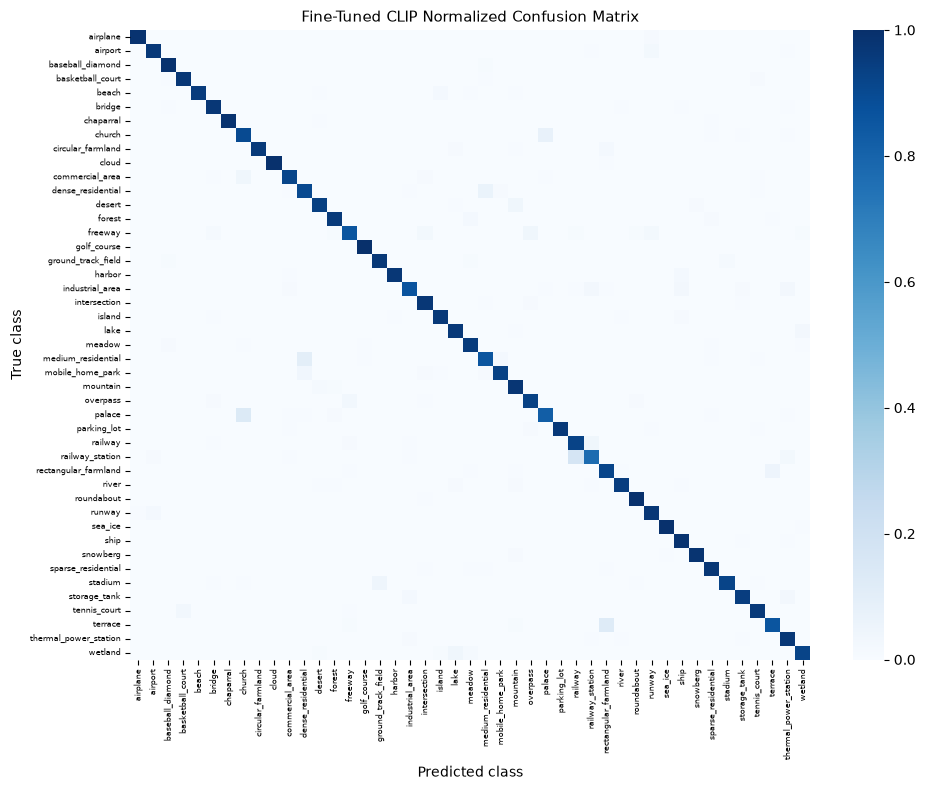

In [65]:
base_labels_np = to_numpy_array(base_full_test_results["labels"]).astype(int)
base_predictions_np = to_numpy_array(base_full_test_results["predictions"]).astype(int)

finetuned_labels_np = to_numpy_array(fine_tuned_full_test_results["labels"]).astype(int)
finetuned_predictions_np = to_numpy_array(fine_tuned_full_test_results["predictions"]).astype(int)

base_cm = confusion_matrix(
    base_labels_np,
    base_predictions_np,
    labels=list(range(num_classes)),
)

ft_cm = confusion_matrix(
    finetuned_labels_np,
    finetuned_predictions_np,
    labels=list(range(num_classes)),
)

ft_cm_normalized = ft_cm.astype(np.float32) / ft_cm.sum(axis=1, keepdims=True)
ft_cm_normalized = np.nan_to_num(ft_cm_normalized)

df_finetuned_top_confusions = get_top_confusions(
    confusion_matrix_array=ft_cm,
    class_names=class_names,
    top_n=10,
)

print("Most frequent fine-tuned confusion pairs:")
display(df_finetuned_top_confusions)

plt.figure(figsize=(10, 8))

sns.heatmap(
    ft_cm_normalized,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot=False,
    cbar=True,
    vmin=0,
    vmax=1,
)

plt.title("Fine-Tuned CLIP Normalized Confusion Matrix", fontsize=11)
plt.xlabel("Predicted class")
plt.ylabel("True class")

plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)

plt.tight_layout()
plt.show()

### Question 2 — Effect of LoRA Fine-Tuning

Compare the base CLIP model and the LoRA fine-tuned CLIP model using the overall comparison table, the per-class improvement table, and the confusion matrices. Did fine-tuning improve the model only slightly, or did it substantially change the classification behavior?

### Answer:

LoRA fine tuning changes the classification behavior substantially and not just slightly and overall table should show a noticeably larger improvement than prompt engineering while the per class table shows broad gains across many categories instead of isolated changes and fine tuned confusion matrix becomes more diagonal and several frequent base model confusions are reduced although visually similar classes can still remain difficult and this indicates that supervised contrastive fine tuning adapts the shared image text space to remote sensing categories rather than merely recalibrating a few predictions

# Part 5 — Text-to-Image Retrieval with CLIP and FAISS

In this part, CLIP embeddings are used for text-to-image retrieval on the RESISC45 test split.

FAISS provides efficient nearest-neighbor search in the embedding space. Since CLIP embeddings are normalized, inner-product search is equivalent to cosine-similarity retrieval.

## 5.1 Section configuration

This cell defines the retrieval query, the Top-k setting, and the batch size used for gallery encoding and search.

In [66]:
PART5_TOP_K = 3
PART5_BATCH_SIZE = FT_EVAL_BATCH_SIZE if "FT_EVAL_BATCH_SIZE" in globals() else BATCH_SIZE

PART5_RETRIEVAL_QUERY = "an overhead view of storage tanks"

# Avoid leaking the old multi-query variable into Part 6.
# Part 6 has its own fallback prompt list.
if "RETRIEVAL_QUERY_EXAMPLES" in globals():
    del RETRIEVAL_QUERY_EXAMPLES

print("Part 5 retrieval configuration")
print("------------------------------")
print("Query:", PART5_RETRIEVAL_QUERY)
print("Top-k:", PART5_TOP_K)
print("Batch size:", PART5_BATCH_SIZE)

Part 5 retrieval configuration
------------------------------
Query: an overhead view of storage tanks
Top-k: 3
Batch size: 16


## 5.2 Select the retrieval model

This cell selects the model used for retrieval.

If the merged fine-tuned CLIP model is available, it is used first. Otherwise, the notebook falls back to the base CLIP model.

In [86]:
def get_retrieval_model():
    if "merged_lora_model" in globals():
        print("Using merged LoRA fine-tuned CLIP model from memory.")
        retrieval_model = merged_lora_model

    elif "MERGED_MODEL_DIR" in globals() and Path(MERGED_MODEL_DIR).exists():
        print("Loading merged LoRA fine-tuned CLIP model from disk.")
        retrieval_model = CLIPModel.from_pretrained(MERGED_MODEL_DIR)

    else:
        print("Fine-tuned model was not found. Falling back to base CLIP.")
        retrieval_model = CLIPModel.from_pretrained(CLIP_MODEL_ID)

    retrieval_model = retrieval_model.to(DEVICE)
    retrieval_model.eval()

    return retrieval_model


retrieval_model = get_retrieval_model()

print("Retrieval model is ready.")
print("Device:", DEVICE)

Loading merged LoRA fine-tuned CLIP model from disk.


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

Retrieval model is ready.
Device: cuda


## 5.3 Build a retrieval dataloader

This cell builds the retrieval gallery from the full RESISC45 test split.

Each image in the gallery becomes one searchable item in the retrieval index.

In [87]:
retrieval_dataset = test_full_dataset

retrieval_loader = DataLoader(
    retrieval_dataset,
    batch_size=PART5_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_pil_batch,
    pin_memory=torch.cuda.is_available(),
)

retrieval_loader_df = pd.DataFrame([
    {
        "gallery": "RESISC45 full test split",
        "num_images": len(retrieval_dataset),
        "batch_size": PART5_BATCH_SIZE,
        "num_batches": len(retrieval_loader),
    }
])

display(retrieval_loader_df)

,gallery,num_images,batch_size,num_batches
0,RESISC45 full test split,6300,16,394


## 5.4 Define embedding helpers for retrieval

This cell defines helper functions for encoding text queries and gallery images.

The embeddings are L2-normalized so that similarity search can be performed with cosine similarity.

In [69]:
@torch.no_grad()
def encode_retrieval_images(model, processor, images, device):
    """
    Encodes a batch of gallery images into normalized CLIP image embeddings.

    Args:
        model: CLIP model used for image encoding.
        processor: CLIP processor for preparing image inputs.
        images (list): List of PIL images.
            - Length: batch_size
        device: Computation device.

    Returns:
        Tensor: Normalized image embeddings.
            - Shape: (batch_size, embedding_dim)
    """
    ################## TODO ##################
    model.eval()
    base_model = unwrap_clip_model(model)
    inputs = processor(
        images=images,
        return_tensors="pt",
    )
    pixel_values = inputs["pixel_values"].to(device)
    vision_outputs = base_model.vision_model(pixel_values=pixel_values)
    image_features = base_model.visual_projection(vision_outputs.pooler_output)
    return F.normalize(image_features, p=2, dim=-1).detach().cpu()
    ##########################################


@torch.no_grad()
def encode_retrieval_texts(model, processor, texts, device):
    """
    Encodes text queries into normalized CLIP text embeddings.

    Args:
        model: CLIP model used for text encoding.
        processor: CLIP processor for preparing text inputs.
        texts (list): List of text queries.
            - Length: num_queries
        device: Computation device.

    Returns:
        Tensor: Normalized text embeddings.
            - Shape: (num_queries, embedding_dim)
    """
    ################## TODO ##################
    model.eval()
    base_model = unwrap_clip_model(model)
    inputs = processor(
        text=texts,
        padding=True,
        truncation=True,
        return_tensors="pt",
    )
    inputs = {
        key: value.to(device) if torch.is_tensor(value) else value
        for key, value in inputs.items()
    }
    text_outputs = base_model.text_model(
        input_ids=inputs["input_ids"],
        attention_mask=inputs.get("attention_mask"),
    )
    text_features = base_model.text_projection(text_outputs.pooler_output)
    return F.normalize(text_features, p=2, dim=-1).detach().cpu()
    ##########################################

## 5.5 Extract image embeddings for the retrieval gallery

This cell encodes all gallery images and stores one CLIP embedding per image.

The result is the feature matrix used to build the retrieval index.

In [88]:
@torch.no_grad()
def build_retrieval_gallery_embeddings(model, processor, dataloader, device):
    """
    Encodes all gallery images and builds a dataframe with their metadata.

    Args:
        model: CLIP model used for image encoding.
        processor: CLIP processor for preparing images.
        dataloader (DataLoader): Dataloader for the retrieval gallery.
        device: Computation device.

    Returns:
        tuple: A tuple containing:
            - image_features (ndarray): Gallery image embeddings.
                - Shape: (num_gallery_images, embedding_dim)
            - gallery_df (DataFrame): Metadata for each gallery image.
    """
    ################## TODO ##################
    feature_batches = []
    metadata_rows = []
    dataset_index = 0

    for batch in tqdm(dataloader, desc="Encoding retrieval gallery"):
        features = encode_retrieval_images(
            model=model,
            processor=processor,
            images=batch["images"],
            device=device,
        )
        feature_batches.append(features.numpy().astype(np.float32))

        for batch_index in range(len(batch["images"])):
            label = int(batch["labels"][batch_index])
            metadata_rows.append({
                "gallery_index": dataset_index,
                "dataset_index": dataset_index,
                "image_id": batch["image_ids"][batch_index],
                "label": label,
                "class_name": batch["class_names"][batch_index],
            })
            dataset_index += 1

    image_features = np.ascontiguousarray(
        np.concatenate(feature_batches, axis=0),
        dtype=np.float32,
    )
    image_features = l2_normalize_numpy(image_features).astype(np.float32)

    return image_features, pd.DataFrame(metadata_rows)
    ##########################################


retrieval_image_embeddings, df_retrieval_gallery = build_retrieval_gallery_embeddings(
    model=retrieval_model,
    processor=processor,
    dataloader=retrieval_loader,
    device=DEVICE,
)

embedding_norms = np.linalg.norm(
    retrieval_image_embeddings,
    axis=1,
)

embedding_check_df = pd.DataFrame([
    {
        "num_gallery_images": retrieval_image_embeddings.shape[0],
        "embedding_dim": retrieval_image_embeddings.shape[1],
        "min_norm": embedding_norms.min(),
        "max_norm": embedding_norms.max(),
        "mean_norm": embedding_norms.mean(),
    }
])

display(embedding_check_df)

Encoding retrieval gallery:   0%|          | 0/394 [00:00<?, ?it/s]

,num_gallery_images,embedding_dim,min_norm,max_norm,mean_norm
0,6300,768,1.0,1.0,1.0


## 5.6 Build a FAISS index

This cell builds the FAISS retrieval index.

FAISS is a library for fast similarity search over dense vectors. Here we use `IndexFlatIP`, which performs exact inner-product search. Because the embeddings are normalized, this is equivalent to exact cosine-similarity retrieval.

In [89]:
embedding_dim = retrieval_image_embeddings.shape[1]

retrieval_index = faiss.IndexFlatIP(embedding_dim)
retrieval_index.add(retrieval_image_embeddings)

print("FAISS index created.")
print("Embedding dimension:", embedding_dim)
print("Indexed images:", retrieval_index.ntotal)

FAISS index created.
Embedding dimension: 768
Indexed images: 6300


## 5.7 Text-to-image retrieval function

This function encodes a text query, searches the FAISS index, and returns the top matching images.

The retrieved results are shown as a compact ranked grid.

In [90]:
def retrieve_images_from_text(
    query,
    model,
    processor,
    index,
    gallery_df,
    hf_dataset,
    device,
    top_k=3,
):
    """
    Retrieves the most similar gallery images for a text query.

    Args:
        query (str): Text query used for retrieval.
        model: CLIP model used for text encoding.
        processor: CLIP processor.
        index: FAISS index containing gallery image embeddings.
        gallery_df (DataFrame): Metadata for gallery images.
        hf_dataset: Hugging Face dataset used to load retrieved images.
        device: Computation device.
        top_k (int, optional): Number of retrieved images. Defaults to 3.

    Returns:
        DataFrame: Ranked retrieval results with image ids, class names, and scores.
    """
    ################## TODO ##################
    text_features = encode_retrieval_texts(
        model=model,
        processor=processor,
        texts=[query],
        device=device,
    ).numpy().astype(np.float32)
    text_features = np.ascontiguousarray(text_features)
    scores, gallery_indices = index.search(
        text_features,
        min(int(top_k), index.ntotal),
    )

    rows = []

    for rank, (gallery_index, score) in enumerate(
        zip(gallery_indices[0], scores[0]),
        start=1,
    ):
        metadata = gallery_df.iloc[int(gallery_index)]
        rows.append({
            "rank": rank,
            "gallery_index": int(gallery_index),
            "dataset_index": int(metadata["dataset_index"]),
            "image_id": metadata["image_id"],
            "label": int(metadata["label"]),
            "class_name": metadata["class_name"],
            "score": float(score),
        })

    results_df = pd.DataFrame(rows)
    display(results_df)

    if not results_df.empty:
        plt.figure(figsize=(4 * len(results_df), 4))

        for plot_index, row in results_df.iterrows():
            image = hf_dataset[int(row["dataset_index"])]["image"].convert("RGB")
            plt.subplot(1, len(results_df), plot_index + 1)
            plt.imshow(image)
            plt.axis("off")
            plt.title(
                f"Rank {int(row['rank'])}: {row['class_name']}\n"
                f"Score: {row['score']:.3f}",
                fontsize=9,
            )

        plt.suptitle(query, fontsize=12)
        plt.tight_layout()
        plt.show()

    return results_df
    ##########################################

## 5.8 Run one retrieval query

This cell runs a single natural-language retrieval query and displays the top retrieved images.

It provides a small qualitative retrieval demo using the CLIP embedding space.

In [91]:
df_single_query_results = retrieve_images_from_text(
    query=PART5_RETRIEVAL_QUERY,
    model=retrieval_model,
    processor=processor,
    index=retrieval_index,
    gallery_df=df_retrieval_gallery,
    hf_dataset=test_full_ds,
    device=DEVICE,
    top_k=PART5_TOP_K,
)

print("Retrieval query:")
print(PART5_RETRIEVAL_QUERY)

print("\nRetrieved classes:")
print(", ".join(df_single_query_results["class_name"].tolist()))

,rank,gallery_index,dataset_index,image_id,label,class_name,score
0,1,4739,4739,storage_tank_039,40,storage_tank,0.353933
1,2,3750,3750,storage_tank_519,40,storage_tank,0.345960
2,3,3508,3508,storage_tank_586,40,storage_tank,0.345187


# Part 6 — Stable Diffusion with the Fine-Tuned CLIP Text Encoder

In this part, we test how the fine-tuned CLIP text encoder affects image generation in Stable Diffusion.

Stable Diffusion is a latent diffusion model: the text encoder maps a prompt to conditioning embeddings, the U-Net denoises latent noise conditioned on these embeddings, and the VAE decodes the final latent into an image.

Here, we replace only the text encoder and compare generation before and after the replacement.

## 6.1 Part 6 configuration

This cell defines the main generation settings for Stable Diffusion, including image size, inference steps, guidance scale, negative prompt, and the test prompts used for comparison.

In [93]:
SD_GENERATION_HEIGHT = 512
SD_GENERATION_WIDTH = 512
SD_NUM_INFERENCE_STEPS = 30
SD_GUIDANCE_SCALE = 7.5
SD_NEGATIVE_PROMPT = "low quality, blurry, distorted, noisy, artifacts"

SD_TEST_PROMPTS = [
    "a satellite image of an airport with runways",
    "an aerial image of a harbor with ships and water",
    "an overhead view of large circular storage tanks",
]

SD_BASE_SEED = 123

SD_DISPLAY_FIGURE_WIDTH = 8
SD_DISPLAY_ROW_HEIGHT = 2.8

print("Part 6 configuration")
print("--------------------")
print("Stable Diffusion model:", SD_MODEL_ID)
print("CLIP model:", CLIP_MODEL_ID)
print("Number of prompts:", len(SD_TEST_PROMPTS))
print("Generation image size:", SD_GENERATION_HEIGHT, "x", SD_GENERATION_WIDTH)
print("Inference steps:", SD_NUM_INFERENCE_STEPS)
print("Guidance scale:", SD_GUIDANCE_SCALE)

print("\nPrompts:")
for prompt in SD_TEST_PROMPTS:
    print("-", prompt)

Part 6 configuration
--------------------
Stable Diffusion model: runwayml/stable-diffusion-v1-5
CLIP model: openai/clip-vit-large-patch14
Number of prompts: 3
Generation image size: 512 x 512
Inference steps: 30
Guidance scale: 7.5

Prompts:
- a satellite image of an airport with runways
- an aerial image of a harbor with ships and water
- an overhead view of large circular storage tanks


## 6.2 Free GPU and CPU memory

In [94]:
objects_to_delete = [
    # Part 0-3 models and helpers
    "model",
    "zero_shot_classifier",
    "prompt_evaluator",

    # Part 4 training objects
    "lora_model",
    "fine_tuner",
    "base_eval_model",

    # Part 5 retrieval objects
    "retrieval_model",
    "retrieval_index",
    "retrieval_image_embeddings",
    "df_retrieval_gallery",
    "df_single_query_results",
    "all_query_results",

    # Previous Part 6 objects, if this section is re-run
    "sd_pipe",
    "base_sd_images",
    "finetuned_sd_images",
    "original_sd_text_encoder",
    "fine_tuned_sd_text_encoder",
    "sd_compatible_text_encoder",
    "fine_tuned_clip_for_sd",
    "fine_tuned_text_source",
    "fine_tuned_clip_source",
    "source_text_state_dict",
    "text_encoder_copy_report",
]

for object_name in objects_to_delete:
    if object_name in globals():
        try:
            del globals()[object_name]
            print(f"Deleted {object_name}.")
        except Exception as error:
            print(f"Could not delete {object_name}:", repr(error))

if "merged_lora_model" in globals():
    if "MERGED_MODEL_DIR" in globals() and Path(MERGED_MODEL_DIR).exists():
        del merged_lora_model
        print("Deleted merged_lora_model because MERGED_MODEL_DIR exists.")
    else:
        merged_lora_model = merged_lora_model.to("cpu")
        print("Kept merged_lora_model on CPU because MERGED_MODEL_DIR was not found.")

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

try:
    import psutil

    process = psutil.Process(os.getpid())
    ram_used_gb = process.memory_info().rss / 1e9
    print(f"Current Python process RAM usage: {ram_used_gb:.2f} GB")
except Exception as error:
    print("Could not report RAM usage:", repr(error))

print("Memory cleanup complete.")

Deleted retrieval_model.
Deleted retrieval_index.
Deleted retrieval_image_embeddings.
Deleted df_retrieval_gallery.
Deleted df_single_query_results.
Deleted sd_pipe.
Deleted base_sd_images.
Deleted finetuned_sd_images.
Deleted original_sd_text_encoder.
Deleted fine_tuned_sd_text_encoder.
Deleted text_encoder_copy_report.
Current Python process RAM usage: 6.36 GB
Memory cleanup complete.


## 6.3 Load Stable Diffusion v1.5

This cell loads the baseline Stable Diffusion v1.5 pipeline.

The scheduler and memory-saving options are configured so the pipeline can run more efficiently in the notebook environment.

In [95]:
SD_PIPELINE_MODEL_ID = SD_MODEL_ID
SD_DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32

sd_pipe = StableDiffusionPipeline.from_pretrained(
    SD_PIPELINE_MODEL_ID,
    torch_dtype=SD_DTYPE,
    safety_checker=None,
    requires_safety_checker=False,
)

sd_pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    sd_pipe.scheduler.config
)

if torch.cuda.is_available():
    sd_pipe = sd_pipe.to(DEVICE)
else:
    sd_pipe = sd_pipe.to("cpu")

sd_pipe.enable_attention_slicing()

try:
    sd_pipe.enable_vae_slicing()
except Exception as error:
    print("Could not enable VAE slicing:", repr(error))

print("Stable Diffusion pipeline loaded.")
print("Pipeline device:", DEVICE)
print("Pipeline dtype:", SD_DTYPE)
print("Original SD text encoder:", type(sd_pipe.text_encoder))

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Stable Diffusion pipeline loaded.
Pipeline device: cuda
Pipeline dtype: torch.float16
Original SD text encoder: <class 'transformers.models.clip.modeling_clip.CLIPTextModel'>


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2273: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


## 6.4 Load the fine-tuned CLIP text encoder and make it Stable-Diffusion-compatible

Stable Diffusion uses a `CLIPTextModel` to encode prompts.

This cell loads the fine-tuned text-encoder weights from Part 4, builds a text encoder with the same configuration as Stable Diffusion, and copies all compatible weights into it.

Only the text-conditioning module is replaced; the U-Net and VAE remain unchanged.

In [96]:
def cleanup_failed_part6_objects():
    for object_name in [
        "fine_tuned_text_source",
        "fine_tuned_clip_source",
        "fine_tuned_sd_text_encoder",
        "source_text_state_dict",
    ]:
        if object_name in globals():
            try:
                del globals()[object_name]
                print(f"Deleted old {object_name}.")
            except Exception as error:
                print(f"Could not delete {object_name}:", repr(error))

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


cleanup_failed_part6_objects()


def load_finetuned_text_encoder_state_dict():
    """
    Loads the fine-tuned CLIP text encoder weights from the merged model directory.

    Args:
        None

    Returns:
        dict: State dictionary of the fine-tuned text encoder.
    """
    ################## TODO ##################
    if "merged_lora_model" in globals():
        fine_tuned_clip_source = merged_lora_model.to("cpu")
    elif Path(MERGED_MODEL_DIR).exists():
        fine_tuned_clip_source = CLIPModel.from_pretrained(
            MERGED_MODEL_DIR,
            torch_dtype=torch.float32,
            low_cpu_mem_usage=True,
        )
    else:
        raise FileNotFoundError(
            f"Fine-tuned merged CLIP model was not found at {MERGED_MODEL_DIR}."
        )

    state_dict = {
        key: value.detach().cpu().clone()
        for key, value in fine_tuned_clip_source.text_model.state_dict().items()
    }

    if "merged_lora_model" not in globals():
        del fine_tuned_clip_source
        gc.collect()

    return state_dict
    ##########################################


def copy_matching_text_weights(source_state_dict, target_text_encoder):
    target_state_dict = target_text_encoder.state_dict()

    copied_keys = []
    skipped_keys = []

    for source_key, source_value in source_state_dict.items():
        candidate_keys = [source_key]

        if source_key.startswith("text_model."):
            candidate_keys.append(source_key.replace("text_model.", "", 1))
        else:
            candidate_keys.append("text_model." + source_key)

        matched = False

        for target_key in candidate_keys:
            if target_key in target_state_dict:
                if target_state_dict[target_key].shape == source_value.shape:
                    target_state_dict[target_key] = source_value.to(
                        dtype=target_state_dict[target_key].dtype
                    )
                    copied_keys.append((source_key, target_key))
                    matched = True
                    break

        if not matched:
            skipped_keys.append(source_key)

    load_result = target_text_encoder.load_state_dict(
        target_state_dict,
        strict=True,
    )

    return {
        "load_result": load_result,
        "copied_keys": copied_keys,
        "skipped_keys": skipped_keys,
        "num_target_keys": len(target_state_dict),
    }


def build_sd_compatible_text_encoder_from_finetuned_weights(sd_pipe):
    """
    Builds a Stable-Diffusion-compatible text encoder using fine-tuned CLIP weights.

    Args:
        sd_pipe: Stable Diffusion pipeline containing the original text encoder config.

    Returns:
        tuple: A tuple containing:
            - sd_compatible_text_encoder: Text encoder compatible with Stable Diffusion.
            - copy_report (dict): Report of copied and skipped weights.
    """
    ################## TODO ##################
    source_state_dict = load_finetuned_text_encoder_state_dict()
    sd_compatible_text_encoder = CLIPTextModel(sd_pipe.text_encoder.config)
    copy_report = copy_matching_text_weights(
        source_state_dict=source_state_dict,
        target_text_encoder=sd_compatible_text_encoder,
    )
    copied_target_keys = {
        target_key
        for _, target_key in copy_report["copied_keys"]
    }
    copy_report["num_copied_target_keys"] = len(copied_target_keys)
    copy_report["copy_fraction"] = (
        len(copied_target_keys) / copy_report["num_target_keys"]
    )

    if copy_report["copy_fraction"] < 0.95:
        raise RuntimeError(
            f"Only {copy_report['copy_fraction']:.2%} of text encoder weights were copied."
        )

    sd_compatible_text_encoder.requires_grad_(False)
    sd_compatible_text_encoder.eval()

    print("Copied text encoder keys:", copy_report["num_copied_target_keys"])
    print("Target text encoder keys:", copy_report["num_target_keys"])
    print(f"Copy fraction: {copy_report['copy_fraction']:.2%}")
    print("Skipped source keys:", len(copy_report["skipped_keys"]))

    del source_state_dict
    gc.collect()

    return sd_compatible_text_encoder, copy_report
    ##########################################


fine_tuned_sd_text_encoder, text_encoder_copy_report = (
    build_sd_compatible_text_encoder_from_finetuned_weights(sd_pipe)
)

print("Fine-tuned SD-compatible text encoder is ready.")
print(type(fine_tuned_sd_text_encoder))

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

Copied text encoder keys: 196
Target text encoder keys: 196
Copy fraction: 100.00%
Skipped source keys: 0
Fine-tuned SD-compatible text encoder is ready.
<class 'transformers.models.clip.modeling_clip.CLIPTextModel'>


## 6.5 Generation helper functions

This cell defines helper functions for image generation and visualization.

The same random seeds are used before and after replacing the text encoder so the comparison is more controlled.

In [97]:
def get_generator(seed):
    """
    Creates a PyTorch random generator for reproducible image generation.

    Args:
        seed (int): Random seed.

    Returns:
        torch.Generator: Seeded generator on CUDA or CPU.
    """
    ################## TODO ##################
    generator_device = "cuda" if torch.cuda.is_available() else "cpu"
    return torch.Generator(device=generator_device).manual_seed(int(seed))
    ##########################################


@torch.no_grad()
def generate_images_with_sd_pipeline(
    pipe,
    prompts,
    negative_prompt=None,
    num_inference_steps=30,
    guidance_scale=7.5,
    height=512,
    width=512,
    base_seed=123,
):
    """
    Generates one image for each prompt using a Stable Diffusion pipeline.

    Args:
        pipe: Stable Diffusion pipeline.
        prompts (list): List of text prompts.
            - Length: num_prompts
        negative_prompt (str, optional): Negative prompt for generation. Defaults to None.
        num_inference_steps (int, optional): Number of denoising steps. Defaults to 30.
        guidance_scale (float, optional): Classifier-free guidance scale. Defaults to 7.5.
        height (int, optional): Generated image height. Defaults to 512.
        width (int, optional): Generated image width. Defaults to 512.
        base_seed (int, optional): Base random seed. Defaults to 123.

    Returns:
        list: Generated PIL images.
            - Length: num_prompts
    """
    ################## TODO ##################
    generated_images = []

    for prompt_index, prompt in enumerate(tqdm(prompts, desc="Generating images")):
        generator = get_generator(base_seed + prompt_index)
        output = pipe(
            prompt=prompt,
            negative_prompt=negative_prompt,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            height=height,
            width=width,
            generator=generator,
        )
        generated_images.append(output.images[0])

    return generated_images
    ##########################################


def show_side_by_side_generation_comparison(
    prompts,
    base_images,
    finetuned_images,
    figure_width=8,
    row_height=2.8,
):
    """
    Displays base and fine-tuned Stable Diffusion outputs side by side.

    Args:
        prompts (list): Prompts used for generation.
            - Length: num_prompts
        base_images (list): Images generated with the original text encoder.
            - Length: num_prompts
        finetuned_images (list): Images generated with the fine-tuned text encoder.
            - Length: num_prompts
        figure_width (float, optional): Width of the figure. Defaults to 8.
        row_height (float, optional): Height per prompt row. Defaults to 2.8.

    Returns:
        None
    """
    ################## TODO ##################
    if not (
        len(prompts) == len(base_images) == len(finetuned_images)
    ):
        raise ValueError("Prompts and image lists must have the same length.")

    figure, axes = plt.subplots(
        len(prompts),
        2,
        figsize=(figure_width, row_height * len(prompts)),
        squeeze=False,
    )

    for row_index, prompt in enumerate(prompts):
        axes[row_index, 0].imshow(base_images[row_index])
        axes[row_index, 0].axis("off")
        axes[row_index, 0].set_title(f"Base Stable Diffusion\n{prompt}", fontsize=9)

        axes[row_index, 1].imshow(finetuned_images[row_index])
        axes[row_index, 1].axis("off")
        axes[row_index, 1].set_title(f"Fine-tuned text encoder\n{prompt}", fontsize=9)

    plt.tight_layout()
    plt.show()
    ##########################################

## 6.6 Generate baseline images with the original Stable Diffusion text encoder

This cell first generates baseline images with the original Stable Diffusion text encoder.

Then it replaces the text encoder with the fine-tuned CLIP version, generates images again with the same prompts and seeds, and displays both outputs side by side for comparison.

Generating baseline Stable Diffusion images...


Generating images:   0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Replacing Stable Diffusion text encoder with the fine-tuned CLIP text encoder...
Generating images with the fine-tuned text encoder...


Generating images:   0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

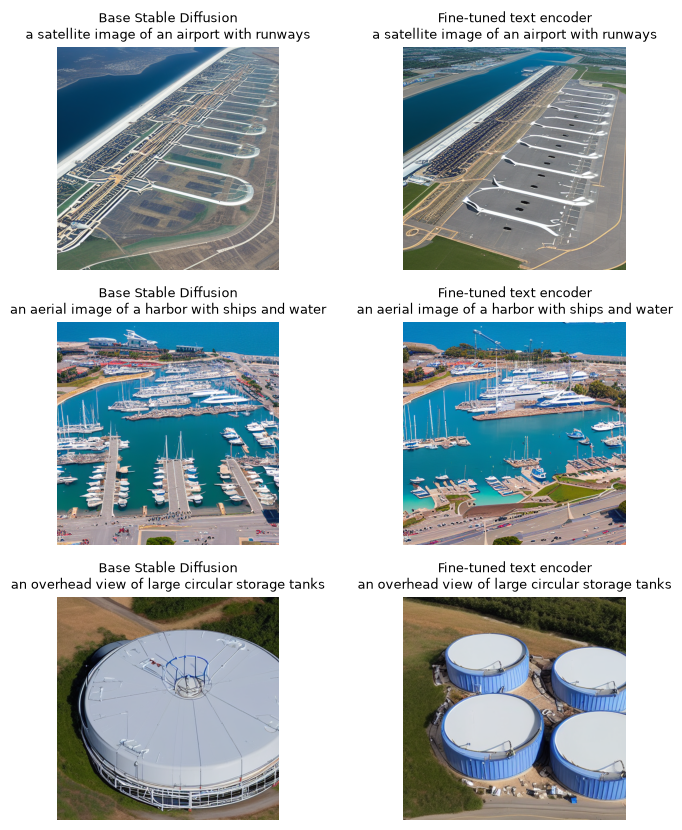

Comparison complete.
Original text encoder: <class 'transformers.models.clip.modeling_clip.CLIPTextModel'>
Fine-tuned text encoder: <class 'transformers.models.clip.modeling_clip.CLIPTextModel'>


In [79]:
original_sd_text_encoder = sd_pipe.text_encoder

print("Generating baseline Stable Diffusion images...")

base_sd_images = generate_images_with_sd_pipeline(
    pipe=sd_pipe,
    prompts=SD_TEST_PROMPTS,
    negative_prompt=SD_NEGATIVE_PROMPT,
    num_inference_steps=SD_NUM_INFERENCE_STEPS,
    guidance_scale=SD_GUIDANCE_SCALE,
    height=SD_GENERATION_HEIGHT,
    width=SD_GENERATION_WIDTH,
    base_seed=SD_BASE_SEED,
)

print("Replacing Stable Diffusion text encoder with the fine-tuned CLIP text encoder...")

sd_pipe.text_encoder = fine_tuned_sd_text_encoder.to(
    device=DEVICE,
    dtype=SD_DTYPE,
)

sd_pipe.text_encoder.eval()

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Generating images with the fine-tuned text encoder...")

finetuned_sd_images = generate_images_with_sd_pipeline(
    pipe=sd_pipe,
    prompts=SD_TEST_PROMPTS,
    negative_prompt=SD_NEGATIVE_PROMPT,
    num_inference_steps=SD_NUM_INFERENCE_STEPS,
    guidance_scale=SD_GUIDANCE_SCALE,
    height=SD_GENERATION_HEIGHT,
    width=SD_GENERATION_WIDTH,
    base_seed=SD_BASE_SEED,
)

show_side_by_side_generation_comparison(
    prompts=SD_TEST_PROMPTS,
    base_images=base_sd_images,
    finetuned_images=finetuned_sd_images,
    figure_width=SD_DISPLAY_FIGURE_WIDTH,
    row_height=SD_DISPLAY_ROW_HEIGHT,
)

print("Comparison complete.")
print("Original text encoder:", type(original_sd_text_encoder))
print("Fine-tuned text encoder:", type(sd_pipe.text_encoder))

### Question 3 — Retrieval and Generation After Fine-Tuning

The fine-tuned CLIP model is used for text-to-image retrieval, and its text encoder is also inserted into Stable Diffusion. Compare the retrieval result for the storage-tank query with the side-by-side Stable Diffusion generations. Does the fine-tuned representation transfer well to both retrieval and generation?

### Answer:

fine tuned representation transfers more reliably to retrieval than to generation and storage tank query should retrieve storage tank images with high similarity because retrieval directly uses fine tuned joint CLIP space and in stable diffusion U Net was trained with the original CLIP text embedding distribution so replacing only the text encoder can change or weaken prompt conditioning even when the encoder is better for RESISC45 classification and therefore retrieval benefits clearly while generation transfer is limited or inconsistent unless the diffusion model is also adapted to the new text representations